In [1]:
import ast
import re
from sentence_transformers import SentenceTransformer
import math
import hashlib
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import deque, Counter, Counter, defaultdict
from typing import List, Tuple

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from catboost import CatBoostClassifier

from itertools import chain
from typing import Tuple



import warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns = None
pd.options.display.max_rows = 100

2026-03-04 08:54:04.531170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772614444.747832      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772614444.809906      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772614445.287067      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772614445.287103      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772614445.287106      55 computation_placer.cc:177] computation placer alr

In [2]:
class Config:
    path = "/kaggle/input/digicow-comp/digicow-farmer-training-adoption-challenge20260210-32396-19ubatl/"
    seed = 21
    n_splits = 5
    drop_cols = ['topics_list']
    id_col = 'ID'
    target_cols = ['adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days']

CFG = Config()

In [3]:
train = pd.read_csv(CFG.path + 'Train.csv')
test = pd.read_csv(CFG.path + 'Test.csv')
prior = pd.read_csv(CFG.path + 'Prior.csv')

print(train.columns)

display(train.head(), train.shape, test.head(), test.shape, prior.head(), prior.shape)

Index(['ID', 'farmer_name', 'training_day', 'gender', 'registration', 'age',
       'group_name', 'belong_to_cooperative', 'county', 'subcounty', 'ward',
       'adopted_within_07_days', 'adopted_within_90_days',
       'adopted_within_120_days', 'has_topic_trained_on', 'trainer',
       'topics_list'],
      dtype='object')


,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on,trainer,topics_list
0,ID_CENCC8,FAR_eqbhscj,2024-01-03,Female,Manual,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"
1,ID_YTO0FF,FAR_qlwtyik,2024-01-03,Female,Manual,Above 35,GRP_zemrbsy,1,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Housing'], ['Poultry Housing']]"
2,ID_1476PE,FAR_somfzxp,2024-01-03,Female,Manual,Above 35,GRP_zmblxsw,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Asili Fertilizer (Organic)', 'Biosecurity I..."
3,ID_MLKLIR,FAR_ongcqyd,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,['TRA_rkvyofbh'],"[['Poultry Products'], ['Record Keeping In Dai..."
4,ID_V5ZVTA,FAR_ztsbhhm,2024-01-03,Female,Ussd,Below 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,['TRA_szrwyfzz'],"[['Ndume App', 'Poultry Feeding']]"


(13536, 17)

,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,has_topic_trained_on,trainer,topics_list
0,ID_LEG1GM,FAR_xzjemuh,2025-05-02,Female,Manual,Above 35,GRP_cerilaa,0,CNT_rihpna,SUB_twzhvtx,WRD_dookztxz,1,['TRA_ubcgvofe'],[['Poultry Health Mngt']]
1,ID_1UKOKW,FAR_qeqddnu,2025-05-02,Female,Manual,Above 35,GRP_xstrxdm,0,CNT_yljqnl,SUB_jchavji,WRD_kmaqgnin,1,['TRA_suiifsur'],"[['Poultry Health Mngt'], ['Herd Health. Manag..."
2,ID_U5H2YK,FAR_kvptshx,2025-05-02,Female,Ussd,Above 35,GRP_diinohf,0,CNT_mvqqmw,SUB_nrjsgty,WRD_gwikueno,1,['TRA_kkzpfdtu'],"[['Poultry Feeding With Tyari'], ['Poultry Man..."
3,ID_55957A,FAR_yfkcdgs,2025-05-02,Female,Manual,Above 35,GRP_diinohf,0,CNT_mvqqmw,SUB_nrjsgty,WRD_gwikueno,1,['TRA_kkzpfdtu'],"[['Poultry Feeding With Tyari'], ['Poultry Man..."
4,ID_N1AC0A,FAR_yqxhbah,2025-05-02,Female,Manual,Above 35,GRP_wnapfuo,0,CNT_yljqnl,SUB_jchavji,WRD_mymgodzd,1,['TRA_suiifsur'],[['Herd Health. Management']]


(5621, 14)

,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on,trainer,topics_list
0,ID_70GP6F,FAR_leopgvh,2024-01-03,Female,Manual,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,TRA_szrwyfzz,"['Ndume App', 'Poultry Feeding']"
1,ID_IWQOWJ,FAR_vdcjfxm,2024-01-03,Female,Ussd,Above 35,GRP_yvpakgc,0,CNT_lpotuu,SUB_lpotuuf,WRD_lpotuufh,0,0,0,0,TRA_szrwyfzz,"['Ndume App', 'Poultry Feeding']"
2,ID_Z3ES85,FAR_hfkybdg,2024-01-03,Female,Manual,Above 35,GRP_zmblxsw,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,TRA_rkvyofbh,"['Asili Fertilizer (Organic)', 'Biosecurity In..."
3,ID_JNZM6R,FAR_hfkybdg,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,0,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,TRA_rkvyofbh,['Poultry Products']
4,ID_BNJ1GU,FAR_hfkybdg,2024-01-03,Female,Manual,Above 35,GRP_psdrfni,1,CNT_fhdsoy,SUB_mdyljqn,WRD_atkhhvon,0,0,0,1,TRA_rkvyofbh,['Record Keeping In Dairy']


(44882, 17)

In [4]:
def parse_and_flatten_topics(x):
    # Step 1: string -> python object
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return []
    
    # Step 2: flatten nested lists
    if isinstance(x, list):
        flat = []
        for item in x:
            if isinstance(item, list):
                flat.extend(item)
            else:
                flat.append(item)
        return flat
    
    return []
train['topics_list'] = train['topics_list'].apply(parse_and_flatten_topics)
test['topics_list']  = test['topics_list'].apply(parse_and_flatten_topics)
prior['topics_list'] = prior['topics_list'].apply(parse_and_flatten_topics)
print(train['topics_list'][1])
print(test['topics_list'][1])
print(prior['topics_list'][1])

['Poultry Housing', 'Poultry Housing']
['Poultry Health Mngt', 'Herd Health. Management']
['Ndume App', 'Poultry Feeding']


In [5]:
test_prior = prior[prior['farmer_name'].isin(test['farmer_name'].unique())].reset_index(drop=True)
print(test_prior['farmer_name'].nunique(), test['farmer_name'].nunique())
train_prior = prior[~(prior['ID'].isin(test_prior['ID'].unique()))].reset_index(drop=True)
test_prior.shape, train_prior.shape , test_prior.shape[0] + train_prior.shape[0]

3526 5621


((28441, 17), (16441, 17), 44882)

In [6]:
df_test = pd.concat([test, test_prior])
df_train = pd.concat([train, train_prior])
df_test.shape, df_train.shape, train.shape, test.shape

((34062, 17), (29977, 17), (13536, 17), (5621, 14))

In [7]:
df_test['ID'].nunique(), df_train['ID'].nunique()

(34062, 29977)

In [8]:
print(df_train.isnull().sum())
print(df_test.isnull().sum())


ID                         0
farmer_name                0
training_day               0
gender                     0
registration               0
age                        0
group_name                 0
belong_to_cooperative      0
county                     0
subcounty                  0
ward                       0
adopted_within_07_days     0
adopted_within_90_days     0
adopted_within_120_days    0
has_topic_trained_on       0
trainer                    0
topics_list                0
dtype: int64
ID                            0
farmer_name                   0
training_day                  0
gender                        0
registration                  0
age                           0
group_name                    0
belong_to_cooperative         0
county                        0
subcounty                     0
ward                          0
has_topic_trained_on          0
trainer                       0
topics_list                   0
adopted_within_07_days     5621
adopted_within

* either predict the whole test even those which were in prior or only the ones that are needed in the sample submission file

In [9]:
def findDifferentialInfo(train, test, __featToExcl=[]):
    '''
    Describe data and difference between train and test datasets.
    
    Arguments:
    train -- the training dataset (pandas DataFrame)
    test -- the test dataset (pandas DataFrame)
    __featToExcl -- list of features to exclude from analysis (default: [])
    target_for_vcramer -- the target variable for calculating Cramer's V coefficient (default: None)
    
    Returns:
    df_stats -- DataFrame containing statistics and differences between train and test datasets
    
    '''
    
    stats = []
    __featToAnalyze = [v for v in list(train.columns) if v not in __featToExcl]

    for col in tqdm(__featToAnalyze):

        dtrain = dict(train[col].value_counts())
        dtest = dict(test[col].value_counts())

        set_train_not_in_test = set(dtest.keys()) - set(dtrain.keys())
        set_test_not_in_train = set(dtrain.keys()) - set(dtest.keys())

        dict_train_not_in_test = {key: value for key, value in dtest.items() if key in set_train_not_in_test}
        dict_test_not_in_train = {key: value for key, value in dtrain.items() if key in set_test_not_in_train}

        nb_moda_test, nb_var_test = len(dtest), pd.Series(dtest).sum()
        nb_moda_abs, nb_var_abs = len(dict_train_not_in_test), pd.Series(dict_train_not_in_test).sum()
        nb_moda_train, nb_var_train = len(dtrain), pd.Series(dtrain).sum()
        nb_moda_abs_2, nb_var_abs_2 = len(dict_test_not_in_train), pd.Series(dict_test_not_in_train).sum()

        stats.append((col, train[col].nunique()
                      , str(nb_moda_abs) + '   (' + str(round(100 * nb_moda_abs / nb_moda_test, 1)) + '%)'
                      , str(nb_moda_abs_2) + '   (' + str(round(100 * nb_moda_abs_2 / nb_moda_train, 1)) + '%)'
                      , str(train[col].isnull().sum()) + '   (' + str(
            round(100 * train[col].isnull().sum() / train.shape[0], 1)) + '%)'
                      , str(test[col].isnull().sum()) + '   (' + str(
            round(100 * test[col].isnull().sum() / test.shape[0], 1)) + '%)'
                      , str(round(100 * train[col].value_counts(normalize=True, dropna=False).values[0], 1))
                      , train[col].dtype))

    df_stats = pd.DataFrame(stats, columns=['Feature'
        , 'Unique values (train)', "Unique values in test not in train (and %)"
        , "Unique values in train not in test (and %)"
        , 'NaN in train (and %)', 'NaN in test (and %)', '% in the biggest cat. (train)'
        , 'dtype'])

    return df_stats
findDifferentialInfo(df_train, df_test, __featToExcl=CFG.drop_cols + [CFG.id_col] + CFG.target_cols)

100%|██████████| 12/12 [00:00<00:00, 52.97it/s]


,Feature,Unique values (train),Unique values in test not in train (and %),Unique values in train not in test (and %),NaN in train (and %),NaN in test (and %),% in the biggest cat. (train),dtype
0,farmer_name,13536,5621 (100.0%),13536 (100.0%),0 (0.0%),0 (0.0%),0.3,object
1,training_day,153,78 (35.3%),10 (6.5%),0 (0.0%),0 (0.0%),3.8,object
2,gender,2,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),72.7,object
3,registration,2,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),66.9,object
4,age,2,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),78.9,object
5,group_name,900,126 (19.6%),384 (42.7%),0 (0.0%),0 (0.0%),2.6,object
6,belong_to_cooperative,2,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),87.5,int64
7,county,9,0 (0.0%),1 (11.1%),0 (0.0%),0 (0.0%),37.9,object
8,subcounty,27,1 (4.3%),5 (18.5%),0 (0.0%),0 (0.0%),34.3,object
9,ward,68,6 (10.0%),14 (20.6%),0 (0.0%),0 (0.0%),34.3,object


In [10]:
NUMERICAL_COLS = [ ]
CFG.drop_cols.extend([ 'farmer_name','group_name', 'ward', 'subcounty', 'county'])
proper_cols = [col for col in df_train if col not in CFG.drop_cols]

BINARY_CATEGORICAL_COLS = [col for col in proper_cols if df_train[col].nunique()==2 and col not in CFG.target_cols + CFG.drop_cols] 
DATE_COLS = ['training_day']

OTHER_CATEGORICAL_COLS = [col for col in df_train.columns if col not in NUMERICAL_COLS + BINARY_CATEGORICAL_COLS 
                         + DATE_COLS + CFG.target_cols + CFG.drop_cols + [CFG.id_col]
                         ]
print(BINARY_CATEGORICAL_COLS)
print(OTHER_CATEGORICAL_COLS)


['gender', 'registration', 'age', 'belong_to_cooperative', 'has_topic_trained_on']
['trainer']


In [11]:
subcounty_unique = list(set(df_test['subcounty'].unique()) - set(df_train['subcounty'].unique()))
subcounty_unique

['SUB_lezqkwu']

In [12]:
df_test[df_test['subcounty'].isin(subcounty_unique)]['county'].value_counts()

county
CNT_rihpna    87
Name: count, dtype: int64

In [13]:
df_train[df_train['county'].isin(['CNT_rihpna'])]['subcounty'].value_counts()

subcounty
SUB_twzhvtx    1368
SUB_ojxwkxf     485
SUB_kzfscqo     180
SUB_mqwodkp      52
Name: count, dtype: int64

In [14]:
df_test['subcounty'] = np.where(
    df_test['subcounty'].isin(subcounty_unique),
    'SUB_mqwodkp',
    df_test['subcounty']
)
list(set(df_test['subcounty'].unique()) - set(df_train['subcounty'].unique()))


[]

In [15]:
ward_unique = list(set(df_test['ward'].unique()) - set(df_train['ward'].unique()))
ward_unique

['WRD_dmkvmjch',
 'WRD_hyderkig',
 'WRD_ruphprud',
 'WRD_fnbkmwkv',
 'WRD_ssbsejju',
 'WRD_iuesnnte']

In [16]:
df_test[df_test['ward'].isin(ward_unique)]['subcounty'].value_counts()

subcounty
SUB_mqwodkp    377
SUB_jsjdatk     60
SUB_ojxwkxf     50
SUB_dhaaasn      8
Name: count, dtype: int64

In [17]:
df_test[df_test['subcounty'].isin(['SUB_mqwodkp', 'SUB_jsjdatk','SUB_ojxwkxf', 'SUB_dhaaasn'])]['ward'].value_counts()

ward
WRD_emtehozd    7553
WRD_cdhsrdxp     748
WRD_epfjdtkr     447
WRD_gmlvebty     280
WRD_cdndmzyb     203
WRD_hyderkig     194
WRD_htgefokm     162
WRD_hujmmvec     110
WRD_hkgcmenl     105
WRD_fnbkmwkv      96
WRD_dmkvmjch      87
WRD_ssbsejju      60
WRD_ruphprud      50
WRD_rabbaiwn      40
WRD_rfzjlvyw      12
WRD_iuesnnte       8
Name: count, dtype: int64

In [18]:
df_train[df_train['group_name'].isin(['GRP_dvpgkbm', 'GRP_frkhuly', 'GRP_glrevit', 'GRP_mvawwul', 'GRP_aqenhmk', 'GRP_fgxptet'])]['ward'].value_counts()

Series([], Name: count, dtype: int64)

In [19]:
df_test['ward'] = np.where(
    df_test['ward'].isin(ward_unique),
    'WRD_epfjdtkr',
    df_test['ward']
)
list(set(df_test['ward'].unique()) - set(df_train['ward'].unique()))

[]

In [20]:
print(df_train['has_topic_trained_on'].value_counts())
for target in CFG.target_cols:
    print(df_train[target].value_counts())

has_topic_trained_on
1    25069
0     4908
Name: count, dtype: int64
adopted_within_07_days
0    29636
1      341
Name: count, dtype: int64
adopted_within_90_days
0    29332
1      645
Name: count, dtype: int64
adopted_within_120_days
0    29058
1      919
Name: count, dtype: int64


In [21]:
def plotNumericalDistributionOnTopOfEachOther(
    train: pd.DataFrame,
    test: pd.DataFrame,
    numerical_cols: list,
    ncols: int = 5,
    figsize_per_row: int = 5,
    # skew handling
    auto_log: bool = True,
    skew_threshold: float = 1.0,   # > 1 is usually strongly skewed
    # outlier handling
    clip_quantiles: tuple = (0.01, 0.99),
    # comparison handling
    common_norm: bool = False,     # False = density normalization separately (recommended)
    stat: str = "density",         # "density" compares shapes; "count" compares absolute counts
    bins: str = "fd",              # good default for skew; can also pass int
):
    """
    Plots numerical distributions for train and test overlaid.
    Improvements for skewed data: optional log transform + quantile clipping + robust binning.

    - auto_log: if True, applies log1p to positively-valued skewed features (or symlog for mixed sign).
    - clip_quantiles: x-limits set to these quantiles (reduces outlier domination).
    - stat="density": compares shapes even if train/test sizes differ.
    """

    num_cols = len(numerical_cols)
    nrows = math.ceil(num_cols / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, figsize_per_row * nrows), facecolor="#EAEAF2")
    fig.tight_layout(pad=3.0)

    # Make axes always 2D for consistent indexing
    axes = np.atleast_2d(axes)

    for i, col in enumerate(numerical_cols):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        if col not in train.columns:
            ax.set_title(f"{col} (missing in train)")
            ax.axis("off")
            continue

        tr = train[col].dropna()
        te = test[col].dropna() if col in test.columns else pd.Series([], dtype=float)

        # Guard: if empty or non-numeric
        if tr.empty:
            ax.set_title(f"{col} (empty)")
            ax.axis("off")
            continue

        # Compute robust x-limits from combined (train+test) for fair comparison
        combined = pd.concat([tr, te], axis=0) if len(te) else tr
        q_low, q_high = combined.quantile(clip_quantiles[0]), combined.quantile(clip_quantiles[1])

        # Decide transform
        use_log = False
        use_symlog = False
        if auto_log:
            skewness = tr.skew()  # train skew as reference
            # Right-skew and non-negative -> log1p helps a lot
            if skewness > skew_threshold and combined.min() >= 0:
                use_log = True
            # Skewed but includes negatives -> symlog scale is safer
            elif abs(skewness) > skew_threshold and combined.min() < 0:
                use_symlog = True

        # Prepare plotting series
        tr_plot = tr.copy()
        te_plot = te.copy()

        xlabel = col
        if use_log:
            tr_plot = np.log1p(tr_plot)
            te_plot = np.log1p(te_plot) if len(te_plot) else te_plot
            # Update x-limits under transform
            q_low_t, q_high_t = np.log1p(max(q_low, 0)), np.log1p(max(q_high, 0))
            ax.set_xlim(q_low_t, q_high_t)
            xlabel = f"{col} (log1p)"
        else:
            # Clip only via xlim (don’t modify values)
            if np.isfinite(q_low) and np.isfinite(q_high) and q_low < q_high:
                ax.set_xlim(q_low, q_high)

        # Plot
        sns.histplot(
            x=tr_plot, ax=ax, color="#58D68D", label="Train",
            fill=True, kde=True, stat=stat, common_norm=common_norm, bins=bins, element="step"
        )
        if col in test.columns and len(te_plot):
            sns.histplot(
                x=te_plot, ax=ax, color="#DE3163", label="Test",
                fill=True, kde=True, stat=stat, common_norm=common_norm, bins=bins, element="step"
            )

        # If we chose symlog, apply axis scale (keeps raw values but log-like tails)
        if use_symlog:
            ax.set_xscale("symlog", linthresh=1.0)
            xlabel = f"{col} (symlog)"

        ax.legend()
        ax.set_ylabel("")
        ax.set_xlabel(xlabel, fontsize=12)
        ax.tick_params(labelsize=10, width=0.5)
        ax.xaxis.offsetText.set_fontsize(8)
        ax.yaxis.offsetText.set_fontsize(8)

    # Remove unused subplots
    for j in range(num_cols, nrows * ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r, c])

    plt.show()


# plotNumericalDistributionOnTopOfEachOther(df_train, df_test, numerical_cols=NUMERICAL_COLS)


No similar categories in the test dataset for column: trainer


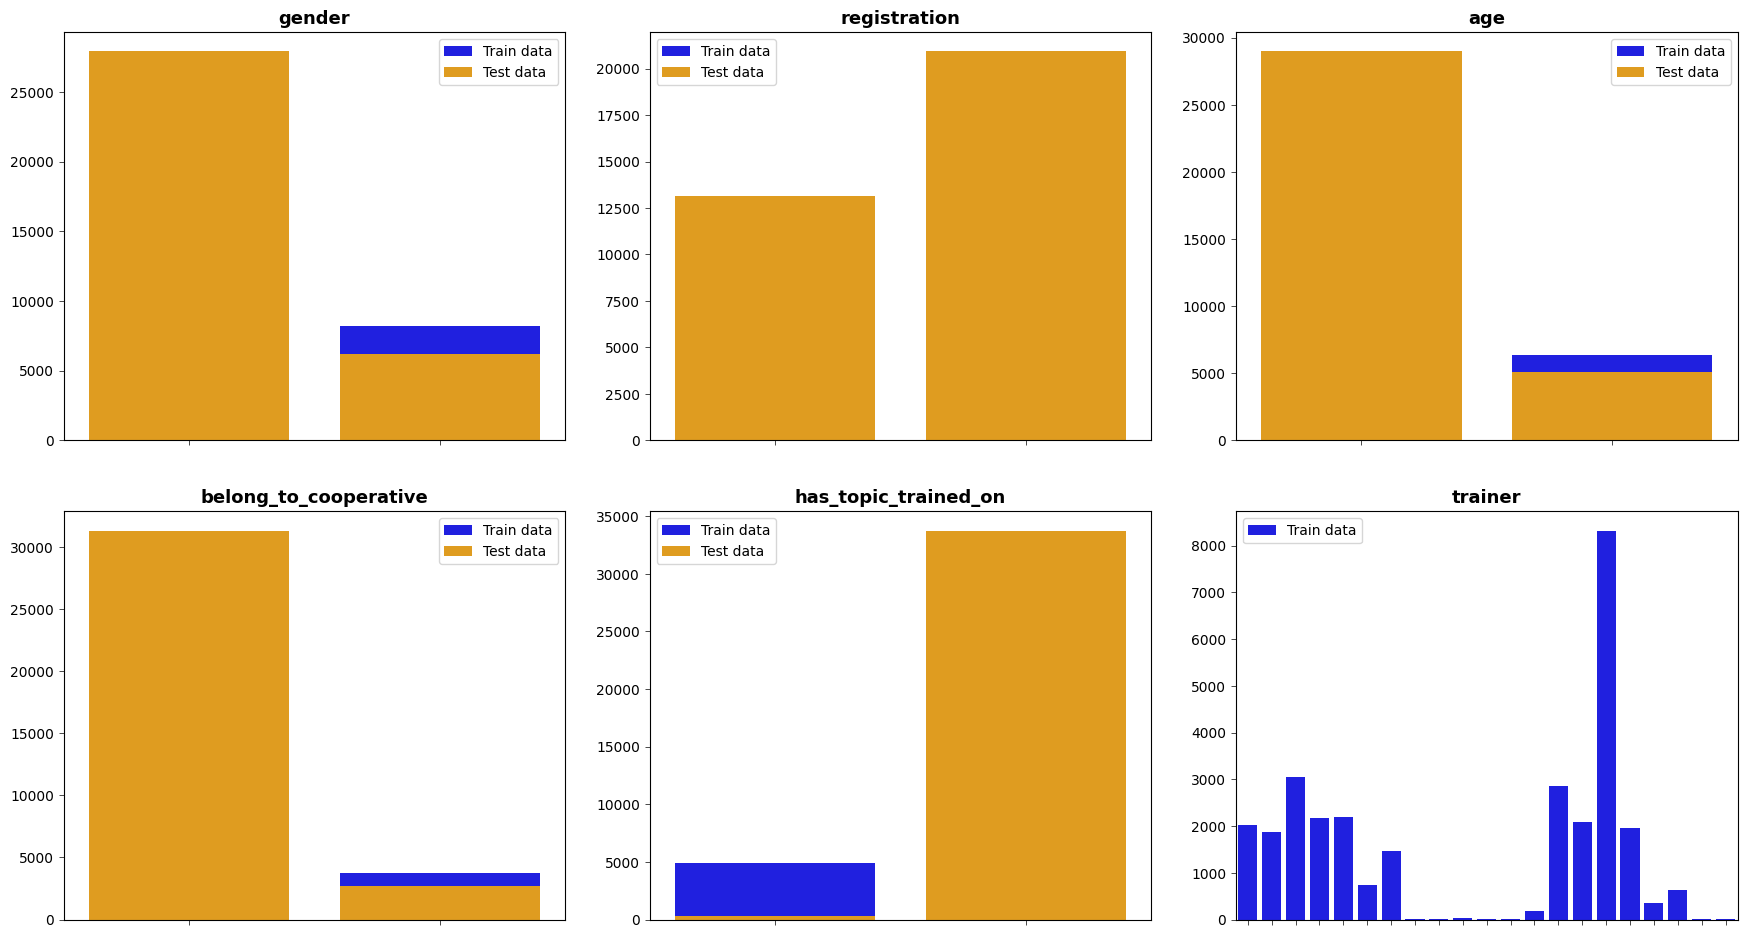

In [22]:
def plotCategoricalDistributionOnTopOfEachOther(train: pd.DataFrame, test: pd.DataFrame, categorical_cols: list):
    """
    Plots categorical distribution for train and test data side by side, with flexibility for handling missing columns.

    Args:
        train (pd.DataFrame): The training data containing categorical columns.
        test (pd.DataFrame): The test data containing categorical columns.
        categorical_cols (list): List of categorical column names.

    Returns:
        None

    Raises:
        None

    """
    if len(categorical_cols) == 0:
        print("No Categorical features")
        return

    num_cols = len(categorical_cols)
    ncols = 3
    nrows = math.ceil(num_cols / ncols)  # Calculate the number of rows dynamically

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = axes.reshape(-1, ncols)  # Reshape axes to be 2-dimensional

    fig.tight_layout(pad=3.0)  # Adjust spacing between subplots

    for r in range(nrows):
        for c in range(ncols):
            idx = r * ncols + c  # Calculate the corresponding index for the categorical column
            if idx < num_cols:
                col = categorical_cols[idx]
                ax = axes[r, c]

                if col in test.columns:  # Check if the column exists in the test data
                    unique_train = train[col].unique()
                    unique_test = test[col].unique()

                    if set(unique_test).issubset(set(unique_train)):
                        sns.countplot(data=train, x=col, ax=ax, color="blue", label='Train data')
                        sns.countplot(data=test, x=col, ax=ax, color="orange", label='Test data')
                    else:
                        print("No similar categories in the test dataset for column:", col)
                        sns.countplot(data=train, x=col, ax=ax, color="blue", label='Train data')
                else:
                    sns.countplot(data=train, x=col, ax=ax, color="blue", label='Train data')

                ax.set_title(col, fontsize=13, fontweight="bold")   # ⭐ COLUMN NAME AS TITLE
                ax.legend()
                ax.set_ylabel('')
                ax.set_xlabel('')
                ax.tick_params(labelsize=10, width=0.5)
                ax.xaxis.offsetText.set_fontsize(8)
                ax.yaxis.offsetText.set_fontsize(8)
                ax.set_xticklabels([])  # Remove x-axis labels

            else:
                fig.delaxes(axes[r, c])  # Remove unused subplot

    plt.show()

plotCategoricalDistributionOnTopOfEachOther(df_train, df_test, categorical_cols = BINARY_CATEGORICAL_COLS + OTHER_CATEGORICAL_COLS)

In [23]:
def parse_if_list_string(x):
    if isinstance(x, str) and x.startswith("[") and x.endswith("]"):
        try:
            return ast.literal_eval(x)
        except:
            return x
    return x

df_train['trainer'] = df_train['trainer'].apply(parse_if_list_string)
df_test['trainer']  = df_test['trainer'].apply(parse_if_list_string)


In [24]:
PLACEHOLDER = "TRA_MULTI"

def normalize_trainer(x):
    if isinstance(x, list):
        if len(x) == 1:
            return x[0]
        else:
            return PLACEHOLDER
    return x

df_train['trainer'] = df_train['trainer'].apply(normalize_trainer)
df_test['trainer']  = df_test['trainer'].apply(normalize_trainer)
print(df_train['trainer'].value_counts(), df_test['trainer'].value_counts())

trainer
TRA_gertumxc    11370
TRA_rkvyofbh     4743
TRA_suiifsur     4157
TRA_kkzpfdtu     2828
TRA_hyodnntj     2528
TRA_szrwyfzz     2218
TRA_ubcgvofe     2092
TRA_twwcfcum       25
TRA_dttdgplk       13
TRA_MULTI           3
Name: count, dtype: int64 trainer
TRA_gertumxc    12413
TRA_suiifsur     8843
TRA_rkvyofbh     5331
TRA_kkzpfdtu     3922
TRA_ubcgvofe     3506
TRA_szrwyfzz       37
TRA_hyodnntj        6
TRA_twwcfcum        2
TRA_MULTI           1
TRA_dttdgplk        1
Name: count, dtype: int64


### Plot Target

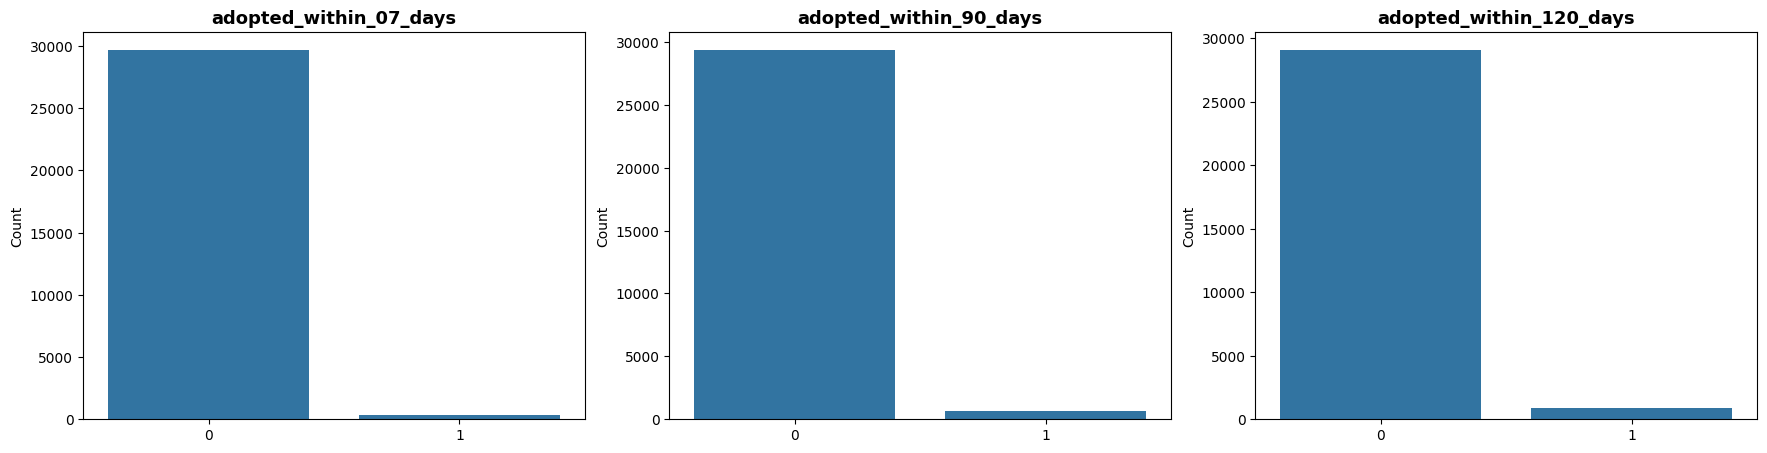

In [25]:
def plot_target(train: pd.DataFrame, target_cols: list, objective: str, ncols: int = 3):
    """
    Plots target variables based on the objective.

    Args:
        train (pd.DataFrame): The training dataset.
        target_cols (list): List of target column names.
        objective (str): Objective of the analysis ('classification' or 'regression').
        ncols (int): Number of subplot columns.

    Returns:
        None

    Raises:
        ValueError: If the objective is not 'classification' or 'regression'.
    """

    if len(target_cols) == 0:
        print("No target columns provided.")
        return

    num_targets = len(target_cols)
    nrows = math.ceil(num_targets / ncols)

    # ================= CLASSIFICATION =================
    if objective == "classification":

        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
        axes = axes.reshape(nrows, ncols)

        fig.tight_layout(pad=3.0)

        for i, col in enumerate(target_cols):
            r, c = divmod(i, ncols)
            ax = axes[r, c]

            sns.countplot(x=col, data=train, ax=ax)

            ax.set_title(f"{col}", fontsize=13, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("Count")

        # Remove empty subplots
        for j in range(num_targets, nrows * ncols):
            r, c = divmod(j, ncols)
            fig.delaxes(axes[r, c])

        plt.show()

    # ================= REGRESSION =================
    elif objective == "regression":

        # ---- Histograms ----
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
        axes = axes.reshape(nrows, ncols)

        fig.tight_layout(pad=3.0)

        for i, col in enumerate(target_cols):
            r, c = divmod(i, ncols)
            ax = axes[r, c]

            sns.histplot(x=col, data=train, kde=True, ax=ax)

            ax.set_title(f"{col} Distribution", fontsize=13, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("Frequency")

        for j in range(num_targets, nrows * ncols):
            r, c = divmod(j, ncols)
            fig.delaxes(axes[r, c])

        plt.show()

        # ---- Boxplots ----
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
        axes = axes.reshape(nrows, ncols)

        fig.tight_layout(pad=3.0)

        for i, col in enumerate(target_cols):
            r, c = divmod(i, ncols)
            ax = axes[r, c]

            sns.boxplot(x=col, data=train, ax=ax)

            ax.set_title(f"{col} Boxplot", fontsize=13, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("Value")

        for j in range(num_targets, nrows * ncols):
            r, c = divmod(j, ncols)
            fig.delaxes(axes[r, c])

        plt.show()

    else:
        raise ValueError("Invalid objective. Must be 'classification' or 'regression'.")
plot_target(df_train, CFG.target_cols, objective="classification")


In [26]:
for col in CFG.target_cols:
    print(df_train[col].value_counts())

adopted_within_07_days
0    29636
1      341
Name: count, dtype: int64
adopted_within_90_days
0    29332
1      645
Name: count, dtype: int64
adopted_within_120_days
0    29058
1      919
Name: count, dtype: int64


In [27]:
df_train['training_day'].min(),df_train['training_day'].max(), df_test['training_day'].min(),df_test['training_day'].max(), 

('2024-01-03', '2025-04-12', '2024-01-04', '2025-12-12')

In [28]:
df_train.shape, df_test.shape

((29977, 17), (34062, 17))

### Analyze Topics Overlap

In [29]:

def parse_topics_cell(x):
    """Return list of clean topic strings from a cell like ['a,b,c'] or a string."""
    # if pd.isna(x):
    #     return []

    if isinstance(x, list):
        topics = x
    elif isinstance(x, str) and x.strip().startswith("[") and x.strip().endswith("]"):
        try:
            topics = ast.literal_eval(x)
        except Exception:
            topics = [x]
    else:
        topics = [str(x)]

    # single comma-separated string inside list
    if len(topics) == 1 and isinstance(topics[0], str) and "," in topics[0]:
        topics = [t.strip() for t in topics[0].split(",") if t.strip()]

    clean = []
    for t in topics:
        t = str(t).strip()
        t = re.sub(r"\s+", " ", t)
        t = t.strip(" .")
        if t:
            clean.append(t)
    return clean


def extract_unique_topics(df: pd.DataFrame, topic_col: str) -> set[str]:
    all_topics = df[topic_col].apply(parse_topics_cell)
    uniq = set()
    for lst in all_topics:
        uniq.update(lst)
    return uniq


def topic_overlap_report(train_df: pd.DataFrame, test_df: pd.DataFrame, topic_col: str = "topics_list"):
    train_topics = extract_unique_topics(train_df, topic_col)
    test_topics  = extract_unique_topics(test_df, topic_col)

    shared = train_topics & test_topics
    train_only = train_topics - test_topics
    test_only  = test_topics - train_topics

    summary = pd.DataFrame({
        "set": ["train_unique", "test_unique", "shared", "train_only", "test_only"],
        "count": [len(train_topics), len(test_topics), len(shared), len(train_only), len(test_only)],
    })

    # % overlap from each side
    summary["pct_of_train"] = np.nan
    summary["pct_of_test"] = np.nan
    if len(train_topics) > 0:
        summary.loc[summary["set"].isin(["shared", "train_only"]), "pct_of_train"] = (
            summary.loc[summary["set"].isin(["shared", "train_only"]), "count"].values / len(train_topics) * 100
        )
        summary.loc[summary["set"] == "test_only", "pct_of_train"] = len(test_only) / len(train_topics) * 100
    if len(test_topics) > 0:
        summary.loc[summary["set"].isin(["shared", "test_only"]), "pct_of_test"] = (
            summary.loc[summary["set"].isin(["shared", "test_only"]), "count"].values / len(test_topics) * 100
        )
        summary.loc[summary["set"] == "train_only", "pct_of_test"] = len(train_only) / len(test_topics) * 100

    return {
        "train_topics": train_topics,
        "test_topics": test_topics,
        "shared_topics": shared,
        "train_only_topics": train_only,
        "test_only_topics": test_only,
        "summary": summary.sort_values("set"),
    }


In [30]:
rep = topic_overlap_report(df_train, df_test, topic_col="topics_list")
display(rep["summary"])

print("Example test-only topics:", list(rep["test_only_topics"])[:20])


,set,count,pct_of_train,pct_of_test
2,shared,123,95.348837,95.348837
4,test_only,6,4.651163,4.651163
1,test_unique,129,NaN,NaN
3,train_only,6,4.651163,4.651163
0,train_unique,129,NaN,NaN


Example test-only topics: ['Importance Of Vaccination', 'Re', 'Hygie', 'Hygiene And He', 'Ung', 'Weed Management']


In [31]:
def add_topic_onehots_train_vocab(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    topic_col: str = "topics_list",
    min_df: int = 5,
    keep_only_shared: bool = True,
    prefix: str = "topic_",
    max_topics: int | None = None,
):
    """
    Creates multi-hot topic columns.

    Vocab is built from TRAIN only (or TRAIN∩TEST if keep_only_shared=True).
    min_df counts TRAIN document frequency (how many rows contain the topic).
    """
    tr = train_df.copy()
    te = test_df.copy()

    # sets for overlap logic
    train_topics = extract_unique_topics(tr, topic_col)
    test_topics  = extract_unique_topics(te, topic_col)

    if keep_only_shared:
        vocab_set = train_topics & test_topics
    else:
        vocab_set = train_topics  # train-only vocab

    # document frequency on TRAIN
    topic_lists = tr[topic_col].apply(parse_topics_cell)
    df_counts = {}
    for lst in topic_lists:
        for t in set(lst):
            if t in vocab_set:
                df_counts[t] = df_counts.get(t, 0) + 1

    df_counts = pd.Series(df_counts).sort_values(ascending=False)

    # filter by min_df and optional cap
    vocab = df_counts[df_counts >= min_df]
    if max_topics is not None:
        vocab = vocab.head(max_topics)
    vocab = vocab.index.tolist()

    def sanitize(name: str) -> str:
        name = name.lower()
        name = re.sub(r"[^a-z0-9]+", "_", name)
        name = re.sub(r"_+", "_", name).strip("_")
        return name

    def onehot(df):
        lists = df[topic_col].apply(parse_topics_cell)
        out = {}
        for t in vocab:
            col = f"{prefix}{sanitize(t)}"
            out[col] = lists.apply(lambda xs: int(t in xs)).astype(np.int8)
        return pd.DataFrame(out, index=df.index)

    tr_oh = onehot(tr)
    te_oh = onehot(te)

    tr = pd.concat([tr, tr_oh], axis=1)
    te = pd.concat([te, te_oh], axis=1)

    return tr, te, tr_oh.columns.tolist(), df_counts


In [32]:
train_oh, test_oh, topic_cols, df_counts = add_topic_onehots_train_vocab(
    df_train, df_test,
    topic_col="topics_list",
    min_df=10,
    keep_only_shared=True,   # ✅ excludes test-only topics automatically
    max_topics=300
)
print(len(topic_cols))

114


In [33]:
topic_freq_map = df_counts.to_dict()
MAX_FREQ = max(topic_freq_map.values()) if topic_freq_map else 1

def max_topic_popularity(x):
    topics = parse_topics_cell(x)
    if not topics:
        return 0.0
    freqs = [topic_freq_map.get(t, 0) / MAX_FREQ for t in topics]
    return float(np.max(freqs))

def min_topic_popularity(x):
    topics = parse_topics_cell(x)
    if not topics:
        return 0.0
    freqs = [topic_freq_map.get(t, 0) / MAX_FREQ for t in topics]
    return float(np.min(freqs))


def mean_topic_popularity_norm(x):
    topics = parse_topics_cell(x)
    if not topics:
        return 0
    return np.mean([topic_freq_map.get(t, 0) / MAX_FREQ for t in topics])

train_oh["min_topic_popularity"] = train_oh["topics_list"].apply(min_topic_popularity)
test_oh["min_topic_popularity"]  = test_oh["topics_list"].apply(min_topic_popularity)

train_oh["max_topic_popularity"] = train_oh["topics_list"].apply(max_topic_popularity)
test_oh["max_topic_popularity"]  = test_oh["topics_list"].apply(max_topic_popularity)

# Optional: spread/contrast signals (often strong)
train_oh["topic_popularity_range"] = train_oh["max_topic_popularity"] - train_oh["min_topic_popularity"]
test_oh["topic_popularity_range"]  = test_oh["max_topic_popularity"] - test_oh["min_topic_popularity"]

train_oh["topic_popularity_ratio"] = train_oh["max_topic_popularity"] / (train_oh["min_topic_popularity"] + 1e-6)
test_oh["topic_popularity_ratio"]  = test_oh["max_topic_popularity"] / (test_oh["min_topic_popularity"] + 1e-6)

RARE_THRESH = 0.03   # try 0.02–0.05

train_oh["has_rare_topic"] = (train_oh["min_topic_popularity"] < RARE_THRESH).astype(int)
test_oh["has_rare_topic"] = (test_oh["min_topic_popularity"] < RARE_THRESH).astype(int)


In [34]:
def topic_set_key(x):
    t = sorted(parse_topics_cell(x))
    s = "||".join(t)
    return hashlib.md5(s.encode()).hexdigest()

train_oh["topic_set_key"] = train_oh["topics_list"].apply(topic_set_key)
test_oh["topic_set_key"]  = test_oh["topics_list"].apply(topic_set_key)
CFG.drop_cols.append('topic_set_key')
set_freq = train_oh["topic_set_key"].value_counts()
train_oh["topic_set_train_freq"] = train_oh["topic_set_key"].map(set_freq).fillna(0).astype(int)
test_oh["topic_set_train_freq"]  = test_oh["topic_set_key"].map(set_freq).fillna(0).astype(int)


In [35]:
from collections import Counter
from itertools import combinations

train_vocab = set().union(*train_oh["topics_list"].apply(parse_topics_cell).apply(set))
topic_freq = Counter()
for x in train_oh["topics_list"]:
    topic_freq.update(set(parse_topics_cell(x)))

RARE_N = 10

def coverage_feats(x):
    t = parse_topics_cell(x)
    if not t:
        return pd.Series({"n_topics":0,"n_unseen":0,"n_rare":0,"frac_unseen":0.0,"frac_rare":0.0})
    n = len(t)
    n_unseen = sum(tt not in train_vocab for tt in t)
    n_rare = sum(topic_freq.get(tt,0) < RARE_N for tt in t if tt in train_vocab)
    return pd.Series({
        "n_topics": n,
        "n_unseen": n_unseen,
        "n_rare": n_rare,
        "frac_unseen": n_unseen / n,
        "frac_rare": n_rare / n,
    })

train_oh = pd.concat([train_oh, train_oh["topics_list"].apply(coverage_feats)], axis=1)
test_oh  = pd.concat([test_oh,  test_oh["topics_list"].apply(coverage_feats)], axis=1)


In [36]:
train_oh.shape, test_oh.shape

((29977, 143), (34062, 143))

In [37]:
def _ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        s = x.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else [v]
            except Exception:
                return [s]
        return [s]
    return [x]

def _to_trainer_id(x):
    """trainer can be like ['TRA_xxx'] or 'TRA_xxx'"""
    xs = _ensure_list(x)
    if len(xs) == 0:
        return np.nan
    return str(xs[0])

def _flatten_topics(topics_cell):
    """
    topics_list looks like [['Ndume App','Poultry Feeding'], ['Poultry Housing'], ...]
    flatten to 1D list of topic strings
    """
    xs = _ensure_list(topics_cell)
    out = []
    for item in xs:
        if isinstance(item, list):
            out.extend([str(t) for t in item])
        else:
            out.append(str(item))
    return [t.strip() for t in out if t and str(t).strip()]

def _shannon_entropy_from_counts(counts: Counter) -> float:
    n = sum(counts.values())
    if n <= 0:
        return np.nan
    ps = np.array([c / n for c in counts.values()], dtype=float)
    return float(-(ps * np.log(ps + 1e-12)).sum())


In [38]:

def add_group_success_features(
    data: pd.DataFrame,
    group_col: str,
    farmer_col: str,
    date_col: str,
    adopt_cols: Tuple[str, ...],
    topics_flat_col: str = "_flat_topics",
    row_order_col: str = "_row_order",
) -> pd.DataFrame:
    """
    Adds trainer-style group features, leakage-safe:
      - group_farmer_volume
      - group_topic_specialization_entropy
      - group_success_rate_<target>                (past-only over labeled rows)
      - group_consistency_std_<target>             (std of past DAILY success rates)
    """
    # Ensure stable, past-only ordering inside each group
    tmp = data.sort_values([group_col, date_col, row_order_col]).copy()

    feat_cols = [
        "group_farmer_volume",
        "group_topic_specialization_entropy",
    ]
    for c in adopt_cols:
        feat_cols += [f"group_success_rate_{c}", f"group_consistency_std_{c}"]

    feats = {k: np.full(len(tmp), np.nan, dtype=float) for k in feat_cols}

    for grp, idxs in tmp.groupby(group_col, sort=False).indices.items():
        seen_farmers = set()
        topic_counts = Counter()

        past_succ = {c: 0 for c in adopt_cols}
        past_tot  = {c: 0 for c in adopt_cols}

        daily_stats = {c: defaultdict(lambda: [0, 0]) for c in adopt_cols}  # day -> [succ, tot]
        seen_days = {c: [] for c in adopt_cols}

        for ix in idxs:
            # ---- write past-only features ----
            feats["group_farmer_volume"][ix] = float(len(seen_farmers))
            feats["group_topic_specialization_entropy"][ix] = _shannon_entropy_from_counts(topic_counts)

            for c in adopt_cols:
                feats[f"group_success_rate_{c}"][ix] = (
                    past_succ[c] / past_tot[c] if past_tot[c] > 0 else np.nan
                )

                if len(seen_days[c]) >= 2:
                    rates = []
                    for d in seen_days[c]:
                        s, t = daily_stats[c][d]
                        if t > 0:
                            rates.append(s / t)
                    feats[f"group_consistency_std_{c}"][ix] = float(np.std(rates)) if len(rates) >= 2 else np.nan
                else:
                    feats[f"group_consistency_std_{c}"][ix] = np.nan

            # ---- update state with CURRENT row ----
            farmer = tmp.at[ix, farmer_col]
            if pd.notna(farmer):
                seen_farmers.add(str(farmer))

            for t in tmp.at[ix, topics_flat_col]:
                topic_counts[t] += 1

            cur_date = tmp.at[ix, date_col]
            for c in adopt_cols:
                v = tmp.at[ix, c]
                if pd.notna(v) and pd.notna(cur_date):
                    v = int(v)
                    past_tot[c] += 1
                    if v == 1:
                        past_succ[c] += 1

                    day_key = pd.Timestamp(cur_date).date()
                    if day_key not in daily_stats[c]:
                        seen_days[c].append(day_key)
                    daily_stats[c][day_key][1] += 1
                    daily_stats[c][day_key][0] += v

    # attach features back to tmp (same index positions)
    for k, arr in feats.items():
        tmp[k] = arr

    # restore original row order by _row_order (and merge back safely)
    tmp = tmp.sort_values(row_order_col).reset_index(drop=True)
    data2 = data.sort_values(row_order_col).reset_index(drop=True)

    keep = [row_order_col] + feat_cols
    return data2.merge(tmp[keep], on=row_order_col, how="left")


In [39]:
def add_farmer_recent_activity_features_leaky(
    data: pd.DataFrame,
    farmer_col: str = "farmer_name",
    date_col: str = "training_day",
    trainer_col: str = "trainer",
    topics_flat_col: str = "_flat_topics",   # list[str]
    row_order_col: str = "_row_order",
    windows_days: List[int] = (7, 90, 120),
    leak_future: bool = True,   # True = uses future rows in window (strong leakage)
) -> pd.DataFrame:
    """
    LEAKY recent activity features per farmer over windows W:
      - farmer_recent_trainings_{W}d
      - farmer_recent_unique_topics_{W}d
      - farmer_recent_unique_trainers_{W}d

    Window definition (LEAKY):
      if leak_future=True:
        include events with date in [cur_date - W, cur_date + W]  (includes FUTURE)
      else:
        include events with date in [cur_date - W, cur_date]      (includes CURRENT)

    Requires:
      - date_col is datetime
      - topics_flat_col is list[str]
      - row_order_col exists for stable tie-breaking
    """
    tmp = data.copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col], errors="coerce")
    tmp = tmp.sort_values([farmer_col, date_col, row_order_col]).reset_index(drop=True)

    windows_days = sorted(list(windows_days))

    out_cols = []
    for w in windows_days:
        out_cols += [
            f"farmer_recent_trainings_{w}d",
            f"farmer_recent_unique_topics_{w}d",
            f"farmer_recent_unique_trainers_{w}d",
        ]
    feats = {c: np.full(len(tmp), np.nan, dtype=np.float32) for c in out_cols}

    for farmer, idxs in tmp.groupby(farmer_col, sort=False).indices.items():
        idxs = list(idxs)

        # Two pointers: maintain a moving window with counters
        left = {w: 0 for w in windows_days}
        right = {w: 0 for w in windows_days}

        # Counters per window
        dq = {w: deque() for w in windows_days}   # store indices currently in window (in order)
        topic_ct = {w: Counter() for w in windows_days}
        trainer_ct = {w: Counter() for w in windows_days}

        def add_event(w, j):
            ixj = idxs[j]
            tr = tmp.at[ixj, trainer_col] if trainer_col in tmp.columns else None
            tops = tmp.at[ixj, topics_flat_col] if topics_flat_col in tmp.columns else []
            if not isinstance(tops, list):
                tops = [] if pd.isna(tops) else [str(tops)]

            dq[w].append(ixj)
            if tr is not None and pd.notna(tr):
                trainer_ct[w][tr] += 1
            for t in tops:
                if t is None:
                    continue
                tt = str(t).strip()
                if tt:
                    topic_ct[w][tt] += 1

        def remove_event(w):
            ix_old = dq[w].popleft()
            tr = tmp.at[ix_old, trainer_col] if trainer_col in tmp.columns else None
            tops = tmp.at[ix_old, topics_flat_col] if topics_flat_col in tmp.columns else []
            if not isinstance(tops, list):
                tops = [] if pd.isna(tops) else [str(tops)]

            if tr is not None and pd.notna(tr):
                trainer_ct[w][tr] -= 1
                if trainer_ct[w][tr] <= 0:
                    del trainer_ct[w][tr]
            for t in tops:
                if t is None:
                    continue
                tt = str(t).strip()
                if not tt:
                    continue
                topic_ct[w][tt] -= 1
                if topic_ct[w][tt] <= 0:
                    del topic_ct[w][tt]

        # We'll advance per row i (in chronological order)
        for i_pos, ix in enumerate(idxs):
            cur_date = tmp.at[ix, date_col]
            if pd.isna(cur_date):
                continue

            for w in windows_days:
                start = cur_date - pd.Timedelta(days=int(w))
                end = cur_date + (pd.Timedelta(days=int(w)) if leak_future else pd.Timedelta(days=0))

                # Ensure right pointer includes all rows with date <= end
                while right[w] < len(idxs):
                    ixr = idxs[right[w]]
                    dr = tmp.at[ixr, date_col]
                    if pd.isna(dr) or dr > end:
                        break
                    add_event(w, right[w])
                    right[w] += 1

                # Drop from left while date < start
                # (dq[w] is ordered by date)
                while dq[w]:
                    ixl = dq[w][0]
                    dl = tmp.at[ixl, date_col]
                    if pd.isna(dl) or dl >= start:
                        break
                    remove_event(w)

                # Now dq[w] contains events in [start, end] (leaky includes current and maybe future)
                feats[f"farmer_recent_trainings_{w}d"][ix] = float(len(dq[w]))
                feats[f"farmer_recent_unique_topics_{w}d"][ix] = float(len(topic_ct[w]))
                feats[f"farmer_recent_unique_trainers_{w}d"][ix] = float(len(trainer_ct[w]))

    # Attach back (merge on row_order)
    out = tmp[[row_order_col]].copy()
    for c in out_cols:
        out[c] = feats[c]

    # Restore original order & merge
    out = out.sort_values(row_order_col).reset_index(drop=True)
    base = data.sort_values(row_order_col).reset_index(drop=True)
    return base.merge(out, on=row_order_col, how="left")

In [40]:
def build_history_aware_features_multitarget_all_rows(
    df_all: pd.DataFrame,
    farmer_col: str = "farmer_name",
    date_col: str = "training_day",
    topics_col: str = "topics_list",
    trainer_col: str = "trainer",
    location_col: str = "county_ward_subcounty",
    id_col: str = "ID",
    adopt_cols: Tuple[str, ...] = (
        "adopted_within_07_days",
        "adopted_within_90_days",
        "adopted_within_120_days",
    ),
    keep_past_topics_string: bool = True,
) -> pd.DataFrame:
    """
    One-pass history-aware features over a single df that already contains prior+current rows.
    Returns ALL rows with features.

    Target-based features are leakage-safe:
    - features at time t use only past labels (<t)
    - per-target states update only when label is not-null (test rows won't update state)

    Adds:
    Farmer timeline:
      - farmer_n_trainings_so_far
      - farmer_days_since_prev_training
      - farmer_days_since_first_training
    Topics:
      - farmer_unique_topics_so_far
      - farmer_topic_cosine_vs_history
      - farmer_past_topics_joined (optional)
    Per-target history:
      - farmer_past_successes_<target>
      - farmer_past_success_rate_<target>
      - farmer_days_since_last_success_<target>
      - farmer_prev_success_<target>
    Density/location:
      - n_farmers_per_location
      - is_new_farmer_to_location
      - past_unique_farmers_per_location
      - same_day_total_per_trainer
      - same_day_total_per_location
    """
    data = df_all.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")

    # ensure target cols exist
    for col in adopt_cols:
        if col not in data.columns:
            data[col] = np.nan

    # ---------- helpers ----------
    def _ensure_list(x):
        if isinstance(x, list):
            return x
        if pd.isna(x):
            return []
        if isinstance(x, str):
            s = x.strip()
            if s.startswith("[") and s.endswith("]"):
                try:
                    v = ast.literal_eval(s)
                    return v if isinstance(v, list) else [str(v)]
                except Exception:
                    return [s]
            return [s]
        return [str(x)]

    # topics
    data["_topics"] = data[topics_col].apply(_ensure_list) if topics_col in data.columns else [[]] * len(data)

    # sort for timeline correctness
    data = data.sort_values([farmer_col, date_col]).reset_index(drop=True)
    data["farmer_trainer_sessions_so_far"] = (
        data.groupby(["farmer_name", "trainer"]).cumcount()
    )

    # ---- Trainer parsing + topics flatten for trainer stats ----
    data["_trainer_id"] = data[trainer_col].apply(_to_trainer_id) if trainer_col in data.columns else np.nan
    data["_flat_topics"] = data[topics_col].apply(_flatten_topics) if topics_col in data.columns else [[]] * len(data)
    
    # We want stable chronological order for trainer features too:
    # Sort by (trainer, date) so "past" is well-defined per trainer
    # If you can have multiple rows same day per trainer, we keep original row order by index.
    data["_row_order"] = np.arange(len(data))

    GROUP_COL = "group_name"
    if GROUP_COL in data.columns:
        # static group size
        data["group_n_farmers"] = data.groupby(GROUP_COL)[farmer_col].transform("nunique")
    
        # farmer new-to-group indicator
        data["group_is_new_farmer"] = (data.groupby([GROUP_COL, farmer_col]).cumcount() == 0).astype(np.int8)
    
        # chronological past unique farmers (past-only)
        gtmp = data.sort_values([GROUP_COL, date_col, "_row_order"]).copy()
        gtmp["_first_farmer_group"] = gtmp["group_is_new_farmer"].astype(np.int8)
        gtmp["group_past_unique_farmers"] = (
            gtmp.groupby(GROUP_COL)["_first_farmer_group"].cumsum().shift().fillna(0).astype(int)
        )
        data = data.merge(gtmp[["_row_order", "group_past_unique_farmers"]], on="_row_order", how="left")
        gtmp.drop(columns=["_first_farmer_group"], inplace=True, errors="ignore")

    
    data = data.sort_values(["_trainer_id", date_col, "_row_order"]).reset_index(drop=True)
    
    # ---- Allocate outputs ----
    trainer_feat_cols = [
        "trainer_farmer_volume",
        "trainer_topic_specialization_entropy",
    ]
    for col in adopt_cols:
        if col.endswith("07_days"):
            trainer_feat_cols += [f"trainer_success_rate_{col}", f"trainer_consistency_std_{col}"]
        elif col.endswith("90_days"):
            trainer_feat_cols += [f"trainer_success_rate_{col}", f"trainer_consistency_std_{col}"]
        # (You can also add 120d if you want)
    
    trainer_feats = {k: np.full(len(data), np.nan, dtype=float) for k in trainer_feat_cols}
    
    # ---- Per-trainer history scan ----
    for trn, idxs in data.groupby("_trainer_id", sort=False).indices.items():
        # volume
        seen_farmers = set()
    
        # topic specialization entropy
        topic_counts = Counter()
    
        # per-target cumulative success rate
        past_succ = {c: 0 for c in adopt_cols}
        past_tot  = {c: 0 for c in adopt_cols}
    
        # per-target daily consistency: keep per-day (succ, tot), then compute std over days seen so far
        daily_stats = {c: defaultdict(lambda: [0, 0]) for c in adopt_cols}  # date -> [succ, tot]
    
        # we'll compute consistency from days strictly in the past
        seen_days = {c: [] for c in adopt_cols}  # store day keys in order of first appearance
    
        for ix in idxs:
            # --- write features (past-only) ---
            trainer_feats["trainer_farmer_volume"][ix] = float(len(seen_farmers))
            trainer_feats["trainer_topic_specialization_entropy"][ix] = _shannon_entropy_from_counts(topic_counts)
    
            for c in adopt_cols:
                # success rate so far (past-only)
                rate = (past_succ[c] / past_tot[c]) if past_tot[c] > 0 else np.nan
                key = f"trainer_success_rate_{c}"
                if key in trainer_feats:
                    trainer_feats[key][ix] = rate
    
                # consistency std so far (std of daily success rates)
                key_std = f"trainer_consistency_std_{c}"
                if key_std in trainer_feats:
                    # daily rates from past days only
                    if len(seen_days[c]) >= 2:
                        rates = []
                        for d in seen_days[c]:
                            s, t = daily_stats[c][d]
                            if t > 0:
                                rates.append(s / t)
                        trainer_feats[key_std][ix] = float(np.std(rates)) if len(rates) >= 2 else np.nan
                    else:
                        trainer_feats[key_std][ix] = np.nan
    
            # --- update state with CURRENT row (only after features) ---
            # volume
            farmer = data.at[ix, farmer_col]
            if pd.notna(farmer):
                seen_farmers.add(str(farmer))
    
            # topics
            for t in data.at[ix, "_flat_topics"]:
                topic_counts[t] += 1
    
            # targets: update only if label present (keeps test rows safe)
            cur_date = data.at[ix, date_col]
            for c in adopt_cols:
                v = data.at[ix, c]
                if pd.notna(v) and pd.notna(cur_date):
                    v = int(v)
                    past_tot[c] += 1
                    if v == 1:
                        past_succ[c] += 1
    
                    day_key = pd.Timestamp(cur_date).date()
                    # record day order on first time
                    if day_key not in daily_stats[c]:
                        seen_days[c].append(day_key)
                    daily_stats[c][day_key][1] += 1
                    daily_stats[c][day_key][0] += v
    
    # Attach trainer features
    for k, arr in trainer_feats.items():
        data[k] = arr

    data = add_group_success_features(
        data,
        group_col="group_name",
        farmer_col=farmer_col,
        date_col=date_col,
        adopt_cols=adopt_cols,
        topics_flat_col="_flat_topics",
        row_order_col="_row_order",
    )

    
    # cleanup trainer temp cols
    data = data.sort_values(["_row_order"]).reset_index(drop=True)
    data = add_farmer_recent_activity_features_leaky(
        data,
        windows_days=[7, 90, 120],
        leak_future=False
    )
    data.drop(columns=["_trainer_id", "_flat_topics", "_row_order"], inplace=True, errors="ignore")


    # topic id mapping
    all_topics = set()
    for xs in data["_topics"].tolist():
        for t in xs:
            tt = str(t).strip() if t is not None else ""
            if tt:
                all_topics.add(tt)
    topic2id = {t: i for i, t in enumerate(sorted(all_topics))}
    inv_topic = {v: k for k, v in topic2id.items()}

    def _topic_ids(xs):
        out = []
        for t in xs:
            tt = str(t).strip() if t is not None else ""
            if tt and tt in topic2id:
                out.append(topic2id[tt])
        return out

    data["_topic_ids"] = data["_topics"].apply(_topic_ids)

    # =========================
    # (1) Non-target density/location features (safe)
    # =========================
    if location_col in data.columns:
        # total unique farmers ever in location (static)
        data["n_farmers_per_location"] = (
            data.groupby(location_col)[farmer_col].transform("nunique")
        )

        # new farmer to location indicator
        data["is_new_farmer_to_location"] = (
            data.groupby([location_col, farmer_col]).cumcount() == 0
        ).astype(np.int8)

        # past unique farmers seen in location (fast, timeline-safe)
        data["_first_farmer_loc"] = data["is_new_farmer_to_location"].astype(np.int8)
        data["past_unique_farmers_per_location"] = (
            data.groupby(location_col)["_first_farmer_loc"].cumsum().shift().fillna(0).astype(int)
        )
        data.drop(columns=["_first_farmer_loc"], inplace=True, errors="ignore")

        # same-day crowding at location
        if id_col in data.columns:
            data["same_day_total_per_location"] = (
                data.groupby([location_col, date_col])[id_col].transform("count")
            )
        else:
            data["same_day_total_per_location"] = (
                data.groupby([location_col, date_col])[farmer_col].transform("count")
            )

    # same-day trainer load
    if trainer_col in data.columns:
        if id_col in data.columns:
            data["same_day_total_per_trainer"] = (
                data.groupby([trainer_col, date_col])[id_col].transform("count")
            )
        else:
            data["same_day_total_per_trainer"] = (
                data.groupby([trainer_col, date_col])[farmer_col].transform("count")
            )

    # =========================
    # (2) History-aware per-farmer scan (target-safe + topic memory)
    # =========================
    # allocate outputs
    base_cols = [
        "farmer_n_trainings_so_far",
        "farmer_days_since_prev_training",
        "farmer_days_since_first_training",
        "farmer_unique_topics_so_far",
        "farmer_topic_cosine_vs_history",
    ]
    if keep_past_topics_string:
        base_cols.append("farmer_past_topics_joined")

    tgt_cols = []
    for col in adopt_cols:
        tgt_cols += [
            f"farmer_past_successes_{col}",
            f"farmer_past_success_rate_{col}",
            f"farmer_days_since_last_success_{col}",
            f"farmer_prev_success_{col}",
            # f"farmer_ever_adopted_{col}"
        ]

    feats = {k: np.full(len(data), np.nan, dtype=object) for k in (base_cols + tgt_cols)}

    for farmer, idxs in data.groupby(farmer_col, sort=False).indices.items():
        past_topics_set = set()
        last_training_date = None
        first_training_date = None

        past_successes = {col: 0 for col in adopt_cols}
        past_total_labeled = {col: 0 for col in adopt_cols}
        last_success_date = {col: None for col in adopt_cols}
        prev_success = {col: np.nan for col in adopt_cols}

        for j, ix in enumerate(idxs):
            cur_date = data.at[ix, date_col]
            if first_training_date is None and pd.notna(cur_date):
                first_training_date = cur_date

            # base
            feats["farmer_n_trainings_so_far"][ix] = j

            # for col in adopt_cols:
            #     feats[f"farmer_ever_adopted_{col}"][ix] = 1 if past_successes[col] > 0 else 0


            feats["farmer_days_since_prev_training"][ix] = (
                np.nan if (last_training_date is None or pd.isna(cur_date) or pd.isna(last_training_date))
                else (cur_date - last_training_date).days
            )
            feats["farmer_days_since_first_training"][ix] = (
                np.nan if (first_training_date is None or pd.isna(cur_date))
                else (cur_date - first_training_date).days
            )

            feats["farmer_unique_topics_so_far"][ix] = len(past_topics_set)

            cur_set = set(data.at[ix, "_topic_ids"])
            if len(cur_set) == 0 or len(past_topics_set) == 0:
                feats["farmer_topic_cosine_vs_history"][ix] = 0.0
            else:
                inter = len(cur_set & past_topics_set)
                denom = (len(cur_set) ** 0.5) * (len(past_topics_set) ** 0.5)
                feats["farmer_topic_cosine_vs_history"][ix] = float(inter / denom) if denom > 0 else 0.0

            if keep_past_topics_string:
                feats["farmer_past_topics_joined"][ix] = (
                    "" if len(past_topics_set) == 0
                    else " | ".join(inv_topic[i] for i in sorted(past_topics_set))
                )

            # per-target (past-only)
            for col in adopt_cols:
                feats[f"farmer_past_successes_{col}"][ix] = past_successes[col]
                feats[f"farmer_past_success_rate_{col}"][ix] = (
                    past_successes[col] / past_total_labeled[col]
                    if past_total_labeled[col] > 0 else np.nan
                )
                feats[f"farmer_prev_success_{col}"][ix] = prev_success[col]

                lsd = last_success_date[col]
                feats[f"farmer_days_since_last_success_{col}"][ix] = (
                    np.nan if (lsd is None or pd.isna(cur_date) or pd.isna(lsd))
                    else (cur_date - lsd).days
                )

            # update state with this row (labels update only if present)
            if pd.notna(cur_date):
                last_training_date = cur_date

            past_topics_set |= cur_set

            for col in adopt_cols:
                v = data.at[ix, col]
                if pd.notna(v):
                    v = int(v)
                    past_total_labeled[col] += 1
                    if v == 1 and pd.notna(cur_date):
                        past_successes[col] += 1
                        last_success_date[col] = cur_date
                    prev_success[col] = float(v)

    # attach
    for k, arr in feats.items():
        data[k] = pd.to_numeric(arr, errors="ignore")

    # cleanup
    data.drop(columns=["_topics", "_topic_ids"], inplace=True, errors="ignore")
    return data


In [41]:
le = LabelEncoder()
def get_date_features(data: pd.DataFrame, date_cols: list, drop_original: bool = False):
    """
    Extracts useful datetime features from date columns.

    Args:
        data (pd.DataFrame): Input dataframe.
        date_cols (list): List of date column names.
        drop_original (bool): Whether to drop original datetime columns.

    Returns:
        pd.DataFrame: DataFrame with added date features.
    """

    for col in date_cols:

        if col not in data.columns:
            print(f"Skipping {col} (not found)")
            continue

        # Convert to datetime
        data[col] = pd.to_datetime(data[col], errors="coerce")

        # Basic calendar features
        data[f"{col}_year"] = data[col].dt.year
        data[f"{col}_month"] = data[col].dt.month
        data[f"{col}_day"] = data[col].dt.day
        data[f"{col}_dayofweek"] = data[col].dt.dayofweek
        data[f"{col}_week"] = data[col].dt.isocalendar().week.astype("int32")

        # Cyclical encoding (important for ML)
        data[f"{col}_month_sin"] = np.sin(2 * np.pi * data[col].dt.month / 12)
        data[f"{col}_month_cos"] = np.cos(2 * np.pi * data[col].dt.month / 12)

        data[f"{col}_dow_sin"] = np.sin(2 * np.pi * data[col].dt.dayofweek / 7)
        data[f"{col}_dow_cos"] = np.cos(2 * np.pi * data[col].dt.dayofweek / 7)

        if drop_original:
            data.drop(columns=[col], inplace=True)

    return data

# ----------------------------
# Helpers
# ----------------------------
def topics_to_text(x):
    """Convert topics_list cell (list or stringified list) into a single clean text string."""
    # if pd.isna(x):
    #     return ""

    if isinstance(x, list):
        topics = x
    elif isinstance(x, str) and x.strip().startswith("[") and x.strip().endswith("]"):
        try:
            topics = ast.literal_eval(x)
        except Exception:
            topics = [x]
    else:
        topics = [str(x)]

    # Handle single comma-separated string inside a list
    if len(topics) == 1 and isinstance(topics[0], str) and "," in topics[0]:
        topics = [t.strip() for t in topics[0].split(",") if t.strip()]

    topics = [str(t).strip() for t in topics if str(t).strip()]
    return " [SEP] ".join(topics)


def add_topic_embeddings(data: pd.DataFrame,
                         col: str = "topics_list",
                         model_name: str = "sentence-transformers/all-MiniLM-L6-v2",
                         batch_size: int = 64,
                         prefix: str = "topics_emb_"):
    """Add embedding columns to data. Returns (data, emb_cols)."""
    texts = data[col].apply(topics_to_text).tolist()

    model = SentenceTransformer(model_name)
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype(np.float32)

    emb_cols = [f"{prefix}{i}" for i in range(emb.shape[1])]
    emb_df = pd.DataFrame(emb, columns=emb_cols, index=data.index)
    data = pd.concat([data, emb_df], axis=1)
    return data, emb_cols


def add_pca_from_train_only(data: pd.DataFrame,
                            emb_cols: list,
                            train_mask: pd.Series,
                            n_components: int = 64,
                            prefix: str = "topics_pca_",
                            random_state: int = 42):
    """
    Fit PCA on train rows only (to avoid leakage), transform all rows.
    Replaces emb_cols with pca cols. Returns (data, pca_cols).
    """
    pca = PCA(n_components=n_components, random_state=random_state, svd_solver="auto")

    X_train = data.loc[train_mask, emb_cols].values
    X_all = data[emb_cols].values

    X_all_pca = pca.fit_transform(X_train)  # fit on train
    # That line returns only train transform, so do proper fit+transform:
    pca.fit(X_train)
    X_all_pca = pca.transform(X_all).astype(np.float32)

    pca_cols = [f"{prefix}{i}" for i in range(n_components)]
    pca_df = pd.DataFrame(X_all_pca, columns=pca_cols, index=data.index)

    data = pd.concat([data, pca_df], axis=1)
    data.drop(columns=emb_cols, inplace=True)

    return data, pca_cols


# ----------------------------
# Main Feature Engineering
# ----------------------------
def feature_engineering(
    train: pd.DataFrame,
    test: pd.DataFrame,
    use_topic_embeddings: bool = True,
    topic_col: str = "topics_list",
    emb_model_name: str = "sentence-transformers/all-MiniLM-L6-v2",
    emb_batch_size: int = 64,
    use_pca: bool = True,
    pca_components: int = 64,
    drop_topic_original: bool = False
):
    """
    End-to-end feature engineering:
      - concatenates train+test
      - date features
      - topic embeddings + PCA (fit PCA on train only)
      - returns train_df, test_df, features
    """

    data = pd.concat([train, test], axis=0).reset_index(drop=True)
    
    # Count trainings per farmer per day
    data["same_day_total_per_trainer"] = data.groupby(["trainer", "training_day"])["ID"].transform("count")
    data["same_day_total_per_group"] = data.groupby(["group_name", "training_day"])["ID"].transform("count")

    data = build_history_aware_features_multitarget_all_rows(data)

    train_ids = set(train[CFG.id_col].unique())
    train_mask = data[CFG.id_col].isin(train_ids)

    # ---- topic embeddings (+ PCA) ----
    pca_cols = []
    if use_topic_embeddings and (topic_col in data.columns):
        data, emb_cols = add_topic_embeddings(
            data,
            col=topic_col,
            model_name=emb_model_name,
            batch_size=emb_batch_size,
            prefix="topics_emb_"
        )

        if use_pca:
            data, pca_cols = add_pca_from_train_only(
                data,
                emb_cols=emb_cols,
                train_mask=train_mask,
                n_components=pca_components,
                prefix="topics_pca_",
                random_state=42
            )

        if drop_topic_original:
            data.drop(columns=[topic_col], inplace=True)

    # ---- Build features list ----
    farmer_cols = [col for col in data.columns if 'farmer_' in col ]
    trainer_cols = [col for col in data.columns if 'trainer_' in col ]
    group_cols = [col for col in data.columns if 'group_' in col ]

    county_cols = [col for col in data.columns if 'county_' in col ]
    subcounty_cols = [col for col in data.columns if 'subcounty_' in col ]
    ward_cols = [col for col in data.columns if 'ward_' in col ]    
    
    
    
    exclude = set(CFG.target_cols + DATE_COLS + [CFG.id_col ,'farmer_past_topics_joined', 'frac_unseen','n_unseen','_topic0','_has_topics'] + CFG.drop_cols)
    features = [col for col in data.columns if col not in exclude]

    # ---- Split back ----
    train_df = data[train_mask].reset_index(drop=True).copy()
    test_df = data[~train_mask].reset_index(drop=True).copy()

    return train_df, test_df, features

train_df, test_df, features = feature_engineering(
    train_oh,
    test_oh,
    use_topic_embeddings=True,
    use_pca=True,
    pca_components=32,     # try 32/64/128
    drop_topic_original=False
)

test_df_train = test_df[~(test_df['ID'].isin(test['ID'].unique()))].reset_index(drop=True)
test_df = test_df[test_df['ID'].isin(test['ID'].unique())].reset_index(drop=True)
train_df = pd.concat([train_df,test_df_train]).reset_index(drop=True)
display(train_df[features].head(), train_df.shape, test_df[features].head(), test_df.shape, features)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

,gender,registration,age,belong_to_cooperative,has_topic_trained_on,trainer,topic_poultry_health_management,topic_poultry_management_practises,topic_the_benefits_of_ndume_app,topic_herd_health_management,topic_feeding_a_lactating_cow,topic_biosecurity_in_poultry_farming,topic_poultry_management_practices,topic_calf_feeding,topic_how_to_succeed_in_breeding,topic_dairy_feed_management,topic_record_keeping_in_poultry,topic_reasons_why_ai_fails_and_solutions,topic_how_to_rear_healthy_chicken_with_biodeal,topic_poultry_diseases_and_biosecurity,topic_poultry_mngt_practices,topic_herd_health,topic_aflatoxin_in_dairy_farming,topic_milking_hygiene,topic_antimicrobial_resistance,topic_dairy_health_management,topic_herd_management,topic_personal_protective_equipment_ppe,topic_diseases_in_dairy_farming,topic_infertility_in_dairy_cows,topic_deworming_your_dairy_animal,topic_poultry_health_management_practices,topic_poultry_housing,topic_dairy_housing,topic_record_keeping_in_dairy,topic_disadvantages_of_natural_mating,topic_feeding_a_dairy_cow,topic_importance_of_mineral_supplementation,topic_biodeal_poultry,topic_unga_dairy_feeds,topic_hygiene_and_health_products,topic_deworming_and_record_keeping_in_animal_health,topic_why_you_should_vaccinate_your_animals,topic_how_to_rear_a_calf_with_unga_products,topic_poultry_feed_and_water_management,topic_how_to_feed_kienyeji_chicken_from_1_day_old_to_maturity,topic_how_to_feed_layers_from_1_day_old_to_maturity,topic_pest_and_disease_management_in_crops,topic_how_to_feed_kienyeji_chicken_for_meat,topic_livestock_management_practices,topic_transition_cow_management_care_for_your_cow_3_weeks_before_and_after_calving,topic_poultry_and_dairy_feeding_with_tyari_feeds,topic_herd_health_practices_with_biodeal_products,topic_poultry_feeding,topic_kienyeji_chicken_rearing_for_october,topic_goat_management_practices,topic_how_to_manage_pest_and_diseases_at_harvesting_stage,topic_asili_fertilizer_organic,topic_ndume_app,topic_importance_of_mineral_supplementation_with_ckl,topic_kienyeji_poultry_feeds,topic_benfits_of_sistema_biogas,topic_sheep_and_goat_management_practices,topic_dairy_hygiene,topic_importance_of_choosing_the_right_seed_variety,topic_pest_and_disease_management_in_maize_and_beans,topic_poultry_feeding_with_tyari,topic_health_and_feeds,topic_weed_management_in_crop,topic_calf_rearing_for_october,topic_harvesting_and_post_harvesting,topic_dairy_nutrition_with_tyari,topic_microp_planting,topic_cow_management_for_october,topic_successfull_breeding_with_crv,topic_biodeal_dairy,topic_sheep_and_goat_rearing,topic_importance_of_vaccinations_and_record,topic_aflatoxin_mitigation_through_good_agricultural_practices,topic_yara_maziwa_pro,topic_weed_management_in_maize_and_beans,topic_causes_of_infertility_in_dairy,topic_production_of_quality_milk,topic_poultry_management_pract,topic_poultry_health_with_biodeal,topic_aflatoxin_mitigation_in_dairy_herds,topic_clean_energy_with_sistema_biogas,topic_animal_management_practices,topic_feed_for_layers,topic_pest_disease_management_during_production,topic_hygiene_and_feeds,topic_silage_making_with_mama_silage_bags,topic_factors_affecting_milk_production,topic_dairy_health,topic_livestock_management_with_biodeal_products,topic_control_of_external_parasites_with_dominex,topic_mama_silage_bags,topic_dairy_and_poultry_nutrition_with_pembe_feeds,topic_poultry_health_mngt,topic_disadvantages_in_natural_mating,topic_some_reasons_why_ai_fails_and_solutions,topic_selling_to_choice_meats,topic_pest_and_diseases_at_harvesting_stage,topic_dairy_cow_feeding,topic_sheep_goat_rearing,topic_digital_finance_with_kcb,topic_poultry_products,topic_microp_topdressing,topic_fodder_conservation,topic_animal_nutrition_with_pembe,topic_general_livestock_management,topic_herd_health_practices,topic_feeds_for_layers,topic_pest_and_disease_management_at_production_stage,topic_importance_of_vaccinating_against_east_coast_fever_ecf,topic_harvesting_post_harvest_handling,topic_benefits_of_sist

(58418, 222)

,gender,registration,age,belong_to_cooperative,has_topic_trained_on,trainer,topic_poultry_health_management,topic_poultry_management_practises,topic_the_benefits_of_ndume_app,topic_herd_health_management,topic_feeding_a_lactating_cow,topic_biosecurity_in_poultry_farming,topic_poultry_management_practices,topic_calf_feeding,topic_how_to_succeed_in_breeding,topic_dairy_feed_management,topic_record_keeping_in_poultry,topic_reasons_why_ai_fails_and_solutions,topic_how_to_rear_healthy_chicken_with_biodeal,topic_poultry_diseases_and_biosecurity,topic_poultry_mngt_practices,topic_herd_health,topic_aflatoxin_in_dairy_farming,topic_milking_hygiene,topic_antimicrobial_resistance,topic_dairy_health_management,topic_herd_management,topic_personal_protective_equipment_ppe,topic_diseases_in_dairy_farming,topic_infertility_in_dairy_cows,topic_deworming_your_dairy_animal,topic_poultry_health_management_practices,topic_poultry_housing,topic_dairy_housing,topic_record_keeping_in_dairy,topic_disadvantages_of_natural_mating,topic_feeding_a_dairy_cow,topic_importance_of_mineral_supplementation,topic_biodeal_poultry,topic_unga_dairy_feeds,topic_hygiene_and_health_products,topic_deworming_and_record_keeping_in_animal_health,topic_why_you_should_vaccinate_your_animals,topic_how_to_rear_a_calf_with_unga_products,topic_poultry_feed_and_water_management,topic_how_to_feed_kienyeji_chicken_from_1_day_old_to_maturity,topic_how_to_feed_layers_from_1_day_old_to_maturity,topic_pest_and_disease_management_in_crops,topic_how_to_feed_kienyeji_chicken_for_meat,topic_livestock_management_practices,topic_transition_cow_management_care_for_your_cow_3_weeks_before_and_after_calving,topic_poultry_and_dairy_feeding_with_tyari_feeds,topic_herd_health_practices_with_biodeal_products,topic_poultry_feeding,topic_kienyeji_chicken_rearing_for_october,topic_goat_management_practices,topic_how_to_manage_pest_and_diseases_at_harvesting_stage,topic_asili_fertilizer_organic,topic_ndume_app,topic_importance_of_mineral_supplementation_with_ckl,topic_kienyeji_poultry_feeds,topic_benfits_of_sistema_biogas,topic_sheep_and_goat_management_practices,topic_dairy_hygiene,topic_importance_of_choosing_the_right_seed_variety,topic_pest_and_disease_management_in_maize_and_beans,topic_poultry_feeding_with_tyari,topic_health_and_feeds,topic_weed_management_in_crop,topic_calf_rearing_for_october,topic_harvesting_and_post_harvesting,topic_dairy_nutrition_with_tyari,topic_microp_planting,topic_cow_management_for_october,topic_successfull_breeding_with_crv,topic_biodeal_dairy,topic_sheep_and_goat_rearing,topic_importance_of_vaccinations_and_record,topic_aflatoxin_mitigation_through_good_agricultural_practices,topic_yara_maziwa_pro,topic_weed_management_in_maize_and_beans,topic_causes_of_infertility_in_dairy,topic_production_of_quality_milk,topic_poultry_management_pract,topic_poultry_health_with_biodeal,topic_aflatoxin_mitigation_in_dairy_herds,topic_clean_energy_with_sistema_biogas,topic_animal_management_practices,topic_feed_for_layers,topic_pest_disease_management_during_production,topic_hygiene_and_feeds,topic_silage_making_with_mama_silage_bags,topic_factors_affecting_milk_production,topic_dairy_health,topic_livestock_management_with_biodeal_products,topic_control_of_external_parasites_with_dominex,topic_mama_silage_bags,topic_dairy_and_poultry_nutrition_with_pembe_feeds,topic_poultry_health_mngt,topic_disadvantages_in_natural_mating,topic_some_reasons_why_ai_fails_and_solutions,topic_selling_to_choice_meats,topic_pest_and_diseases_at_harvesting_stage,topic_dairy_cow_feeding,topic_sheep_goat_rearing,topic_digital_finance_with_kcb,topic_poultry_products,topic_microp_topdressing,topic_fodder_conservation,topic_animal_nutrition_with_pembe,topic_general_livestock_management,topic_herd_health_practices,topic_feeds_for_layers,topic_pest_and_disease_management_at_production_stage,topic_importance_of_vaccinating_against_east_coast_fever_ecf,topic_harvesting_post_harvest_handling,topic_benefits_of_sist

(5621, 222)

['gender',
 'registration',
 'age',
 'belong_to_cooperative',
 'has_topic_trained_on',
 'trainer',
 'topic_poultry_health_management',
 'topic_poultry_management_practises',
 'topic_the_benefits_of_ndume_app',
 'topic_herd_health_management',
 'topic_feeding_a_lactating_cow',
 'topic_biosecurity_in_poultry_farming',
 'topic_poultry_management_practices',
 'topic_calf_feeding',
 'topic_how_to_succeed_in_breeding',
 'topic_dairy_feed_management',
 'topic_record_keeping_in_poultry',
 'topic_reasons_why_ai_fails_and_solutions',
 'topic_how_to_rear_healthy_chicken_with_biodeal',
 'topic_poultry_diseases_and_biosecurity',
 'topic_poultry_mngt_practices',
 'topic_herd_health',
 'topic_aflatoxin_in_dairy_farming',
 'topic_milking_hygiene',
 'topic_antimicrobial_resistance',
 'topic_dairy_health_management',
 'topic_herd_management',
 'topic_personal_protective_equipment_ppe',
 'topic_diseases_in_dairy_farming',
 'topic_infertility_in_dairy_cows',
 'topic_deworming_your_dairy_animal',
 'topic_p

In [42]:
train_df[features].apply(lambda x: x.nunique())

gender                      2
registration                2
age                         2
belong_to_cooperative       2
has_topic_trained_on        2
                         ... 
topics_pca_27            3046
topics_pca_28            3040
topics_pca_29            3038
topics_pca_30            3027
topics_pca_31            3031
Length: 207, dtype: int64

In [43]:
train_df[[col for col in features if train_df[col].nunique()< 100]].apply(lambda x: x.nunique())

gender                                            2
registration                                      2
age                                               2
belong_to_cooperative                             2
has_topic_trained_on                              2
                                                 ..
farmer_prev_success_adopted_within_07_days        2
farmer_past_successes_adopted_within_90_days     21
farmer_prev_success_adopted_within_90_days        2
farmer_past_successes_adopted_within_120_days    33
farmer_prev_success_adopted_within_120_days       2
Length: 143, dtype: int64

In [44]:
test_df[[col for col in features if train_df[col].nunique()< 100]].apply(lambda x: x.nunique())

gender                                            2
registration                                      2
age                                               2
belong_to_cooperative                             2
has_topic_trained_on                              2
                                                 ..
farmer_prev_success_adopted_within_07_days        2
farmer_past_successes_adopted_within_90_days     17
farmer_prev_success_adopted_within_90_days        2
farmer_past_successes_adopted_within_120_days    21
farmer_prev_success_adopted_within_120_days       2
Length: 143, dtype: int64

In [45]:
for col in [col for col in features if train_df[col].nunique()< 100]:
    print(col)
    print(len(set(test_df[col].unique())- set(train_df[col].unique())))

gender
0
registration
0
age
0
belong_to_cooperative
0
has_topic_trained_on
0
trainer
0
topic_poultry_health_management
0
topic_poultry_management_practises
0
topic_the_benefits_of_ndume_app
0
topic_herd_health_management
0
topic_feeding_a_lactating_cow
0
topic_biosecurity_in_poultry_farming
0
topic_poultry_management_practices
0
topic_calf_feeding
0
topic_how_to_succeed_in_breeding
0
topic_dairy_feed_management
0
topic_record_keeping_in_poultry
0
topic_reasons_why_ai_fails_and_solutions
0
topic_how_to_rear_healthy_chicken_with_biodeal
0
topic_poultry_diseases_and_biosecurity
0
topic_poultry_mngt_practices
0
topic_herd_health
0
topic_aflatoxin_in_dairy_farming
0
topic_milking_hygiene
0
topic_antimicrobial_resistance
0
topic_dairy_health_management
0
topic_herd_management
0
topic_personal_protective_equipment_ppe
0
topic_diseases_in_dairy_farming
0
topic_infertility_in_dairy_cows
0
topic_deworming_your_dairy_animal
0
topic_poultry_health_management_practices
0
topic_poultry_housing
0
top

In [46]:
train_df['same_day_total_per_group'].nunique(), test_df['same_day_total_per_group'].nunique()

(184, 87)

### Study the Target Behavior

In [47]:
for col in CFG.target_cols:
    print(train_df[col].value_counts())

adopted_within_07_days
0.0    57601
1.0      817
Name: count, dtype: int64
adopted_within_90_days
0.0    56676
1.0     1742
Name: count, dtype: int64
adopted_within_120_days
0.0    56029
1.0     2389
Name: count, dtype: int64


In [48]:
subset_120 = train_df[train_df['adopted_within_120_days']==1.0]
subset_120[CFG.target_cols]

,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days
57,1.0,1.0,1.0
110,1.0,1.0,1.0
135,0.0,0.0,1.0
203,0.0,0.0,1.0
204,0.0,0.0,1.0
...,...,...,...
58244,0.0,0.0,1.0
58246,0.0,0.0,1.0
58248,0.0,0.0,1.0
58257,0.0,1.0,1.0


In [49]:
subset_7 = train_df[train_df['adopted_within_07_days']==1.0]
subset_7[CFG.target_cols].describe()

,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days
count,817.0,817.0,817.0
mean,1.0,1.0,1.0
std,0.0,0.0,0.0
min,1.0,1.0,1.0
25%,1.0,1.0,1.0
50%,1.0,1.0,1.0
75%,1.0,1.0,1.0
max,1.0,1.0,1.0


In [50]:
subset_90 = train_df[train_df['adopted_within_90_days']==1.0]
subset_90[CFG.target_cols].describe()

,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days
count,1742.000000,1742.0,1742.0
mean,0.469001,1.0,1.0
std,0.499181,0.0,0.0
min,0.000000,1.0,1.0
25%,0.000000,1.0,1.0
50%,0.000000,1.0,1.0
75%,1.000000,1.0,1.0
max,1.000000,1.0,1.0


### Cross Validation

In [51]:
train_df['skf_col'] = train_df['adopted_within_07_days'].astype(str) + '_' + train_df['adopted_within_90_days'].astype(str) + '_' + train_df['adopted_within_120_days'].astype(str)
train_df['skf_col'].value_counts()

skf_col
0.0_0.0_0.0    56029
0.0_1.0_1.0      925
1.0_1.0_1.0      817
0.0_0.0_1.0      647
Name: count, dtype: int64

In [52]:
MIN_SAMPLES = 10

vc = train_df["skf_col"].value_counts()
rare_classes = vc[vc < MIN_SAMPLES].index

train_df["skf_col_strat"] = train_df["skf_col"]
train_df.loc[train_df["skf_col"].isin(rare_classes), "skf_col_strat"] = "-1"


In [53]:
train_df["fold"] = -1

rare_mask = train_df["skf_col_strat"] == "-1"

rare_df = train_df[rare_mask]
main_df = train_df[~rare_mask]


In [54]:
skf = StratifiedGroupKFold(
    n_splits=CFG.n_splits,
    shuffle=True,
    random_state=CFG.seed
)

for fold, (_, val_idx) in enumerate(
        skf.split(main_df, main_df["skf_col_strat"], groups=main_df['farmer_name'])
    ):
    idx = main_df.iloc[val_idx].index
    train_df.loc[idx, "fold"] = fold


In [55]:
train_df['fold'].value_counts()

fold
0    12336
2    12064
4    11690
1    11256
3    11072
Name: count, dtype: int64

In [56]:
train_df.groupby('fold')[CFG.target_cols[0]].value_counts()

fold  adopted_within_07_days
0     0.0                       12186
      1.0                         150
1     0.0                       11090
      1.0                         166
2     0.0                       11895
      1.0                         169
3     0.0                       10915
      1.0                         157
4     0.0                       11515
      1.0                         175
Name: count, dtype: int64

### MODELLING

In [57]:
NORM_LOGLOSS = 0.5692600484645235  # your constant

def blended_score(y_true, y_pred, norm_logloss=NORM_LOGLOSS, eps=1e-15):
    """
    score = 0.3*AUC + 0.7*(1 - logloss/norm_logloss)
    Higher is better.
    """
    y_pred = np.clip(y_pred, eps, 1 - eps)

    ll = log_loss(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_pred)
    except ValueError:
        auc = np.nan

    score = 0.3 * auc + 0.7 * (1 - ll / norm_logloss) if not np.isnan(auc) else np.nan
    return score, ll, auc


In [58]:
cat_features = BINARY_CATEGORICAL_COLS + OTHER_CATEGORICAL_COLS +topic_cols                                
for col in cat_features:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')

In [59]:
train_df.shape, test_df.shape

((58418, 225), (5621, 222))

In [60]:


TARGETS = [
    "adopted_within_07_days",
    "adopted_within_90_days",
    "adopted_within_120_days",
]

N_SPLITS = CFG.n_splits  # e.g. 5

# --- Storage ---
metrics = {t: {"logloss": [], "roc": [], "score": []} for t in TARGETS}

# out-of-fold preds (for proper overall metrics if you want)
oof = {t: np.full(len(train_df), np.nan, dtype=np.float32) for t in TARGETS}

# test preds per target (we'll average across folds)
test_pred_sum = {t: np.zeros(len(test_df), dtype=np.float32) for t in TARGETS}

# If you used "rare always training" approach with fold == -1:
always_train_mask = train_df["fold"] == -1

# Optional: cast features once for speed if needed (esp. if many object cols already encoded)
X_test = test_df[features]

for fold in range(N_SPLITS):
    # Train/Val split indices
    val_mask = train_df["fold"] == fold
    train_mask = (~val_mask)  # includes other folds AND fold==-1 rows automatically

    train_idx = train_df.index[train_mask]
    val_idx = train_df.index[val_mask]

    X_train = train_df.loc[train_idx, features]
    X_val   = train_df.loc[val_idx, features]

    # per-target training
    for target in TARGETS:
        y_train = train_df.loc[train_idx, target]
        y_val   = train_df.loc[val_idx, target]

        # CatBoost (fast + good defaults)
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="Logloss",
            iterations=1000,               # rely on early stopping
            learning_rate=0.05,
            depth=8,
            random_seed=CFG.seed + fold,
            verbose=200,
            early_stopping_rounds=200,
            use_best_model=True,
            thread_count=-1,  
            task_type='GPU',
            devices = "0:1",
            cat_features = cat_features #topic_cols
        )

        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
        )

        # -------- Validation preds --------
        val_pred = model.predict_proba(X_val)[:, 1].astype(np.float32)
        # -------- Test preds --------
        test_pred = model.predict_proba(X_test)[:, 1].astype(np.float32)
        test_pred_sum[target] += test_pred / N_SPLITS


        # Store OOF
        oof[target][val_idx] = val_pred

        # Metrics for this fold
        fold_logloss = log_loss(y_val, val_pred)
        # ROC AUC can fail if y_val has only one class in that fold
        try:
            fold_roc = roc_auc_score(y_val, val_pred)
        except ValueError:
            fold_roc = np.nan

        fold_score, fold_logloss, fold_roc = blended_score(y_val, val_pred)
        
        metrics[target]["logloss"].append(fold_logloss)
        metrics[target]["roc"].append(fold_roc)
        metrics[target]["score"].append(fold_score)
        
        print(
            f"[Fold {fold}] {target} | "
            f"logloss={fold_logloss:.5f} | "
            f"roc={fold_roc if not np.isnan(fold_roc) else 'nan'} | "
            f"score={fold_score if not np.isnan(fold_score) else 'nan'}"
        )
        print("-"* 100)
        print()


0:	learn: 0.5851280	test: 0.5844863	best: 0.5844863 (0)	total: 345ms	remaining: 5m 45s
200:	learn: 0.0204754	test: 0.0249936	best: 0.0249936 (200)	total: 22.3s	remaining: 1m 28s
400:	learn: 0.0154639	test: 0.0233096	best: 0.0232987 (396)	total: 44.4s	remaining: 1m 6s
600:	learn: 0.0131828	test: 0.0230625	best: 0.0230015 (542)	total: 1m 6s	remaining: 44.4s
bestTest = 0.02300151869
bestIteration = 542
Shrink model to first 543 iterations.
[Fold 0] adopted_within_07_days | logloss=0.02300 | roc=0.9880734722906067 | score=0.9681379217583388
----------------------------------------------------------------------------------------------------

0:	learn: 0.5915157	test: 0.5899304	best: 0.5899304 (0)	total: 115ms	remaining: 1m 54s
200:	learn: 0.0385399	test: 0.0410726	best: 0.0410726 (200)	total: 22.5s	remaining: 1m 29s
400:	learn: 0.0306893	test: 0.0375894	best: 0.0375894 (400)	total: 45.4s	remaining: 1m 7s
600:	learn: 0.0264522	test: 0.0365703	best: 0.0365665 (594)	total: 1m 8s	remaining: 45.

In [61]:
print("\n===== CV Summary =====")
all_score_means = []

for t in TARGETS:
    ll = np.array(metrics[t]["logloss"], dtype=float)
    rc = np.array(metrics[t]["roc"], dtype=float)
    sc = np.array(metrics[t]["score"], dtype=float)

    print(
        f"{t}: "
        f"logloss mean={np.nanmean(ll):.5f} | "
        f"roc mean={np.nanmean(rc):.5f} | "
        f"score mean={np.nanmean(sc):.5f}"
    )

    all_score_means.append(np.nanmean(sc))

print(f"\nOverall mean blended score = {np.nanmean(all_score_means):.5f}")

# -----------------------
# Attach predictions (optional)
# -----------------------
for t in TARGETS:
    train_df[f"oof_{t}"] = oof[t]
    test_df[f"pred_{t}"] = test_pred_sum[t]

train_df.to_csv("cat_oof_train.csv", index=False)
test_df.to_csv("cat_oof_test.csv", index=False)


===== CV Summary =====
adopted_within_07_days: logloss mean=0.02429 | roc mean=0.98934 | score mean=0.96693
adopted_within_90_days: logloss mean=0.04112 | roc mean=0.98566 | score mean=0.94514
adopted_within_120_days: logloss mean=0.05294 | roc mean=0.98350 | score mean=0.92995

Overall mean blended score = 0.94734


In [62]:
train_we_care_about = train_df[train_df['ID'].isin(train['ID'].unique())].reset_index(drop=True)
mean_scores = []
for t in TARGETS:
    print(f"Evaluating Target: {t}")
    oof_target = f"oof_{t}"
    print(f"Roc score: {roc_auc_score(train_we_care_about[t], train_we_care_about[oof_target])}")
    print(f"Logloss : {log_loss(train_we_care_about[t], train_we_care_about[oof_target])}")
    fold_score, fold_logloss, fold_roc = blended_score(train_we_care_about[t], train_we_care_about[oof_target])
    print(f"Blended_score : {fold_score}")
    mean_scores.append(fold_score)
    print("-"* 100)

print("overal mean score", np.mean(mean_scores))

Evaluating Target: adopted_within_07_days
Roc score: 0.9887995647585294
Logloss : 0.022165558982417316
Blended_score : 0.9693836245364172
----------------------------------------------------------------------------------------------------
Evaluating Target: adopted_within_90_days
Roc score: 0.9835757590213363
Logloss : 0.02797713347748798
Blended_score : 0.960670184462648
----------------------------------------------------------------------------------------------------
Evaluating Target: adopted_within_120_days
Roc score: 0.9820364113306383
Logloss : 0.034704298677688636
Blended_score : 0.9519362106033294
----------------------------------------------------------------------------------------------------
overal mean score 0.9606633398674648


In [63]:

SCALING = 0.56926
EPS = 1e-15

def calculate_weighted_score(
    target_07_auc, target_07_logloss,
    target_90_auc, target_90_logloss,
    target_120_auc, target_120_logloss,
    scaling: float = SCALING
):
    t07_ll_norm  = 1 - (target_07_logloss  / scaling)
    t90_ll_norm  = 1 - (target_90_logloss  / scaling)
    t120_ll_norm = 1 - (target_120_logloss / scaling)

    return (
        target_07_auc * 0.15 +
        t07_ll_norm   * 0.65 +
        target_90_auc * 0.05 +
        t90_ll_norm   * 0.05 +
        target_120_auc * 0.05 +
        t120_ll_norm   * 0.05
    )

# ---- evaluate OOF with weighted score ----
train_we_care_about = train_df[train_df["ID"].isin(train["ID"].unique())].reset_index(drop=True)

t07, t90, t120 = TARGETS

# Clip preds for logloss stability
p07  = np.clip(train_we_care_about[f"oof_{t07}"].values.astype(float), EPS, 1 - EPS)
p90  = np.clip(train_we_care_about[f"oof_{t90}"].values.astype(float), EPS, 1 - EPS)
p120 = np.clip(train_we_care_about[f"oof_{t120}"].values.astype(float), EPS, 1 - EPS)

y07  = train_we_care_about[t07].values.astype(int)
y90  = train_we_care_about[t90].values.astype(int)
y120 = train_we_care_about[t120].values.astype(int)

auc07  = roc_auc_score(y07, p07)
auc90  = roc_auc_score(y90, p90)
auc120 = roc_auc_score(y120, p120)

ll07  = log_loss(y07, p07)
ll90  = log_loss(y90, p90)
ll120 = log_loss(y120, p120)

weighted = calculate_weighted_score(
    target_07_auc=auc07, target_07_logloss=ll07,
    target_90_auc=auc90, target_90_logloss=ll90,
    target_120_auc=auc120, target_120_logloss=ll120,
)

print("=== OOF (overall) ===")
print(f"{t07}: AUC={auc07:.6f} | Logloss={ll07:.6f}")
print(f"{t90}: AUC={auc90:.6f} | Logloss={ll90:.6f}")
print(f"{t120}: AUC={auc120:.6f} | Logloss={ll120:.6f}")
print(f"\nWeighted score = {weighted:.6f}")


=== OOF (overall) ===
adopted_within_07_days: AUC=0.988800 | Logloss=0.022166
adopted_within_90_days: AUC=0.983576 | Logloss=0.027977
adopted_within_120_days: AUC=0.982036 | Logloss=0.034704

Weighted score = 0.965786


### Submission

In [64]:
final_test = test_df[test_df['ID'].isin(test['ID'].unique())].reset_index(drop=True)
display(final_test.shape, final_test.head())

(5621, 225)

,ID,farmer_name,training_day,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,adopted_within_07_days,adopted_within_90_days,adopted_within_120_days,has_topic_trained_on,trainer,topics_list,topic_poultry_health_management,topic_poultry_management_practises,topic_the_benefits_of_ndume_app,topic_herd_health_management,topic_feeding_a_lactating_cow,topic_biosecurity_in_poultry_farming,topic_poultry_management_practices,topic_calf_feeding,topic_how_to_succeed_in_breeding,topic_dairy_feed_management,topic_record_keeping_in_poultry,topic_reasons_why_ai_fails_and_solutions,topic_how_to_rear_healthy_chicken_with_biodeal,topic_poultry_diseases_and_biosecurity,topic_poultry_mngt_practices,topic_herd_health,topic_aflatoxin_in_dairy_farming,topic_milking_hygiene,topic_antimicrobial_resistance,topic_dairy_health_management,topic_herd_management,topic_personal_protective_equipment_ppe,topic_diseases_in_dairy_farming,topic_infertility_in_dairy_cows,topic_deworming_your_dairy_animal,topic_poultry_health_management_practices,topic_poultry_housing,topic_dairy_housing,topic_record_keeping_in_dairy,topic_disadvantages_of_natural_mating,topic_feeding_a_dairy_cow,topic_importance_of_mineral_supplementation,topic_biodeal_poultry,topic_unga_dairy_feeds,topic_hygiene_and_health_products,topic_deworming_and_record_keeping_in_animal_health,topic_why_you_should_vaccinate_your_animals,topic_how_to_rear_a_calf_with_unga_products,topic_poultry_feed_and_water_management,topic_how_to_feed_kienyeji_chicken_from_1_day_old_to_maturity,topic_how_to_feed_layers_from_1_day_old_to_maturity,topic_pest_and_disease_management_in_crops,topic_how_to_feed_kienyeji_chicken_for_meat,topic_livestock_management_practices,topic_transition_cow_management_care_for_your_cow_3_weeks_before_and_after_calving,topic_poultry_and_dairy_feeding_with_tyari_feeds,topic_herd_health_practices_with_biodeal_products,topic_poultry_feeding,topic_kienyeji_chicken_rearing_for_october,topic_goat_management_practices,topic_how_to_manage_pest_and_diseases_at_harvesting_stage,topic_asili_fertilizer_organic,topic_ndume_app,topic_importance_of_mineral_supplementation_with_ckl,topic_kienyeji_poultry_feeds,topic_benfits_of_sistema_biogas,topic_sheep_and_goat_management_practices,topic_dairy_hygiene,topic_importance_of_choosing_the_right_seed_variety,topic_pest_and_disease_management_in_maize_and_beans,topic_poultry_feeding_with_tyari,topic_health_and_feeds,topic_weed_management_in_crop,topic_calf_rearing_for_october,topic_harvesting_and_post_harvesting,topic_dairy_nutrition_with_tyari,topic_microp_planting,topic_cow_management_for_october,topic_successfull_breeding_with_crv,topic_biodeal_dairy,topic_sheep_and_goat_rearing,topic_importance_of_vaccinations_and_record,topic_aflatoxin_mitigation_through_good_agricultural_practices,topic_yara_maziwa_pro,topic_weed_management_in_maize_and_beans,topic_causes_of_infertility_in_dairy,topic_production_of_quality_milk,topic_poultry_management_pract,topic_poultry_health_with_biodeal,topic_aflatoxin_mitigation_in_dairy_herds,topic_clean_energy_with_sistema_biogas,topic_animal_management_practices,topic_feed_for_layers,topic_pest_disease_management_during_production,topic_hygiene_and_feeds,topic_silage_making_with_mama_silage_bags,topic_factors_affecting_milk_production,topic_dairy_health,topic_livestock_management_with_biodeal_products,topic_control_of_external_parasites_with_dominex,topic_mama_silage_bags,topic_dairy_and_poultry_nutrition_with_pembe_feeds,topic_poultry_health_mngt,topic_disadvantages_in_natural_mating,topic_some_reasons_why_ai_fails_and_solutions,topic_selling_to_choice_meats,topic_pest_and_diseases_at_harvesting_stage,topic_dairy_cow_feeding,topic_sheep_goat_rearing,topic_digital_finance_with_kcb,topic_poultry_products,topic_microp_topdressing,topic_fodder_conservation,topic_animal_nutrition_with_pembe,topic_general_livestock_management,topic_herd_health_practices,topic_feeds_for_layers,topic_pest_and_disease_management

Text(0.5, 1.0, 'CatBoostClassifier features importance (top 50):')

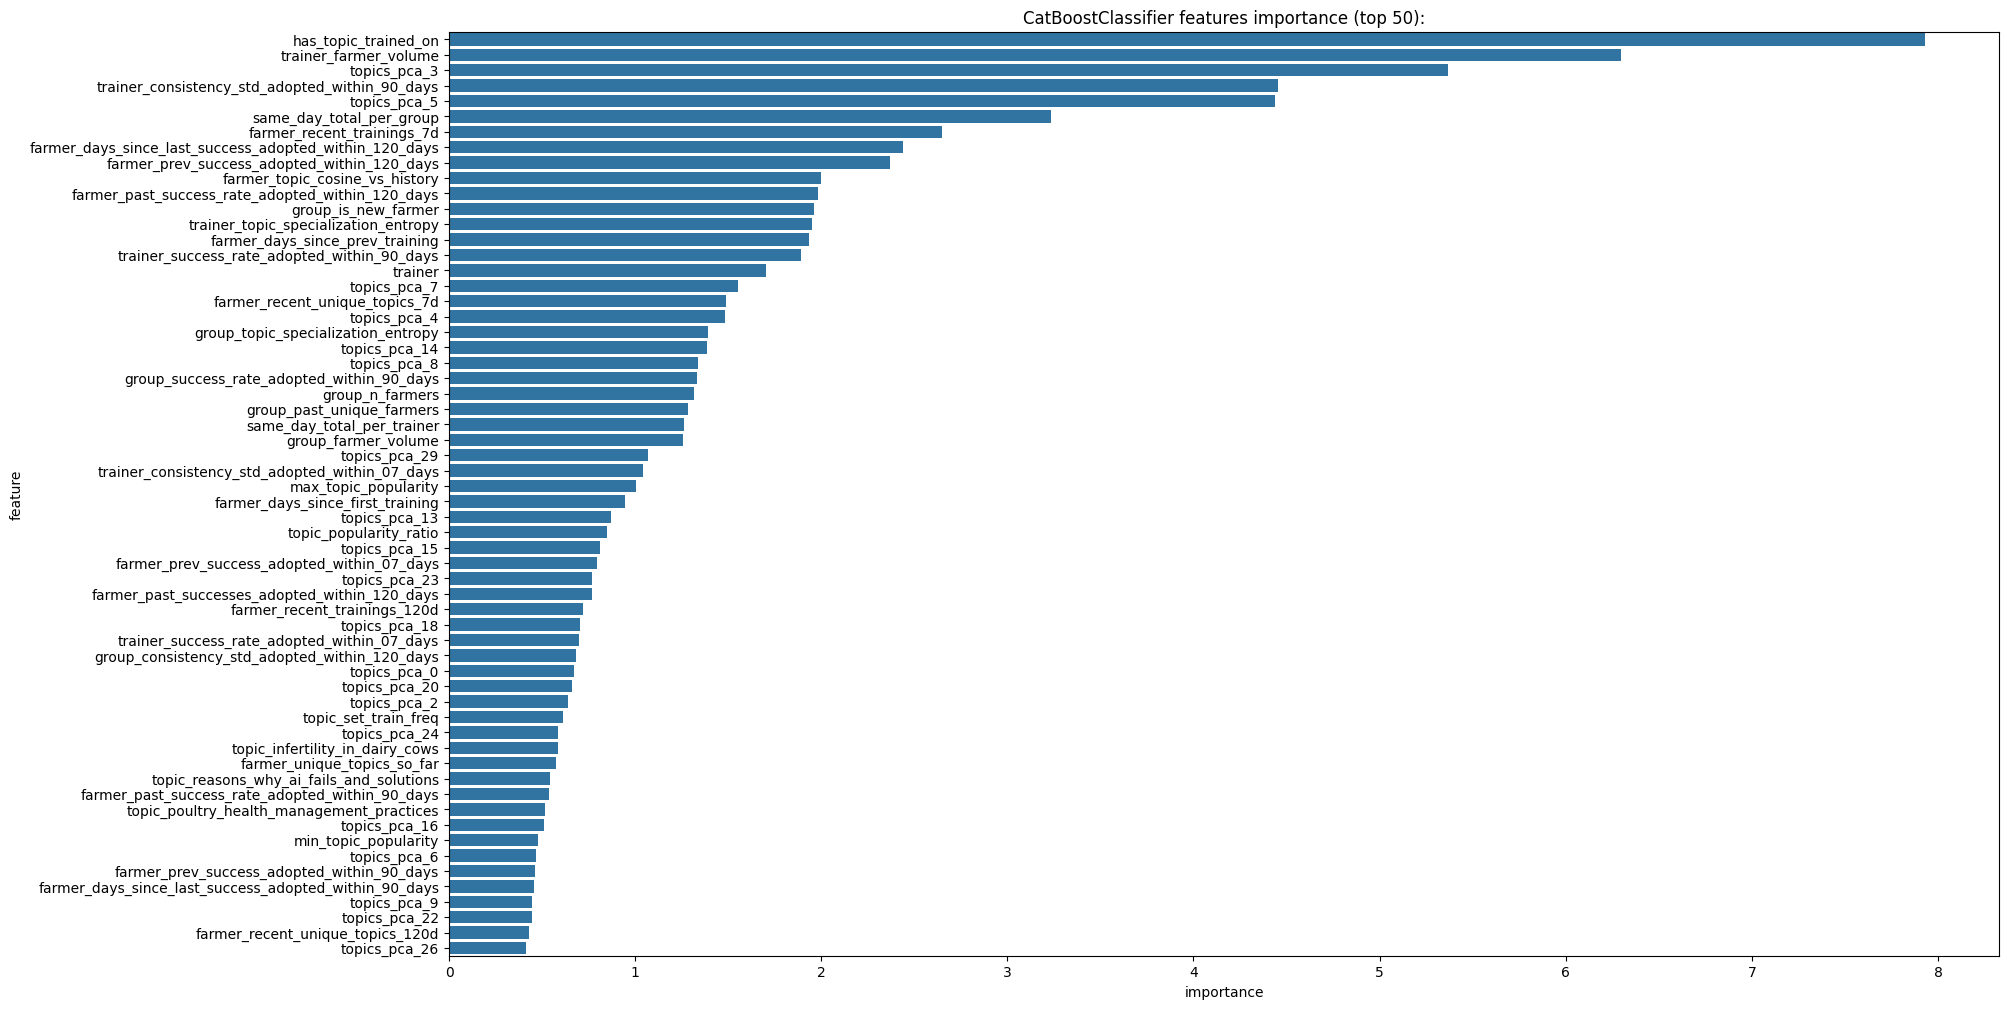

In [65]:
feature_importance_df = pd.DataFrame(model.feature_importances_, columns=['importance'])
feature_importance_df['feature'] = features

plt.figure(figsize=(20, 12));
sns.barplot(x="importance", y="feature", data=feature_importance_df.sort_values(by = ['importance'], ascending = False).head(60))
plt.title('CatBoostClassifier features importance (top 50):')

In [66]:
final_test['Target_07_AUC'] = final_test['pred_adopted_within_07_days']
final_test['Target_07_LogLoss'] = final_test['pred_adopted_within_07_days']
final_test['Target_90_AUC'] = final_test['pred_adopted_within_90_days']
final_test['Target_90_LogLoss'] = final_test['pred_adopted_within_90_days']
final_test['Target_120_AUC'] = final_test['pred_adopted_within_120_days']
final_test['Target_120_LogLoss'] = final_test['pred_adopted_within_120_days']

sub = final_test[['ID','Target_07_AUC', 'Target_07_LogLoss','Target_90_AUC', 'Target_90_LogLoss','Target_120_AUC', 'Target_120_LogLoss' ]]
sub.head()

,ID,Target_07_AUC,Target_07_LogLoss,Target_90_AUC,Target_90_LogLoss,Target_120_AUC,Target_120_LogLoss
0,ID_HZO9J4,0.000266,0.000266,0.001109,0.001109,0.002810,0.002810
1,ID_HKTMZS,0.000140,0.000140,0.000307,0.000307,0.000402,0.000402
2,ID_ECH1M4,0.000024,0.000024,0.000249,0.000249,0.000310,0.000310
3,ID_UG6RWR,0.000011,0.000011,0.000009,0.000009,0.000030,0.000030
4,ID_VA8YS0,0.000362,0.000362,0.000812,0.000812,0.001495,0.001495


In [69]:
sub.to_csv("catboost_digicow_5folds_0_9606_groupedkfold_farmername.csv", index=False)